# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [15]:
# Import warnings
# Import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
# Import the libraries you will be using for analysis

print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.8.4
seaborn version: 0.13.2


In [17]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.8.4
seaborn version: 0.13.2


In [18]:
import os

os.listdir(r'C:\Users\Admin\NYC')

['.ipynb_checkpoints',
 '2023-1.parquet',
 '2023-10.parquet',
 '2023-11.parquet',
 '2023-12.parquet',
 '2023-2.parquet',
 '2023-3.parquet',
 '2023-4.parquet',
 '2023-5.parquet',
 '2023-6.parquet',
 '2023-7.parquet',
 '2023-8.parquet',
 '2023-9.parquet',
 'EDA_Assg_NYC_Taxi_Starter.ipynb',
 'sampled_nyc_taxi.parquet',
 'taxi_zones.dbf',
 'taxi_zones.prj',
 'taxi_zones.sbn',
 'taxi_zones.sbx',
 'taxi_zones.shp',
 'taxi_zones.shp.xml',
 'taxi_zones.shx']

### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [21]:
# Try loading one file

df = pd.read_parquet('2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [27]:
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [28]:
df[['tpep_pickup_datetime', 'pickup_date', 'pickup_hour']].head()

,tpep_pickup_datetime,pickup_date,pickup_hour
0,2023-01-01 00:32:10,2023-01-01,0
1,2023-01-01 00:55:08,2023-01-01,0
2,2023-01-01 00:25:04,2023-01-01,0
3,2023-01-01 00:03:48,2023-01-01,0
4,2023-01-01 00:10:29,2023-01-01,0


In [29]:
import pandas as pd
print("Pandas imported successfully")

Pandas imported successfully


In [30]:
sampled_data = pd.DataFrame()
print(sampled_data)


Empty DataFrame
Columns: []
Index: []


In [31]:
sampled_data = (
    df.groupby(['pickup_date', 'pickup_hour'], group_keys=False)
      .sample(frac=0.05, random_state=42)
      .reset_index(drop=True)
)

In [32]:
print("Original rows:", len(df))
print("Sampled rows:", len(sampled_data))

Original rows: 3041714
Sampled rows: 152087


In [33]:
sampled_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,2022-12-31,23
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,None,68,45,0,...,0.0,0.5,0.00,0.0,1.0,39.30,NaN,NaN,2023-01-01,0
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0,2023-01-01,0
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,1.0,0.5,3.05,0.0,1.0,15.25,2.5,0.0,2023-01-01,0
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,3.5,0.5,4.60,0.0,1.0,23.10,2.5,0.0,2023-01-01,0


In [34]:
for date in df['pickup_date'].unique():
    
    for hour in range(24):
        
        hour_data = df[
            (df['pickup_date'] == date) &
            (df['pickup_hour'] == hour)
        ]
        
        if len(hour_data) > 0:
            sample = hour_data.sample(
                frac=0.05,
                random_state=42
            )
            
            sampled_data = pd.concat(
                [sampled_data, sample]
            )

In [35]:
sampled_data.shape

(304174, 21)

In [36]:
sampled_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,2022-12-31,23
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,None,68,45,0,...,0.0,0.5,0.00,0.0,1.0,39.30,NaN,NaN,2023-01-01,0
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0,2023-01-01,0
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,1.0,0.5,3.05,0.0,1.0,15.25,2.5,0.0,2023-01-01,0
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,3.5,0.5,4.60,0.0,1.0,23.10,2.5,0.0,2023-01-01,0


In [37]:
for date in df['pickup_date'].unique():
    
    for hour in range(24):
        
        hour_data = df[
            (df['pickup_date'] == date) &
            (df['pickup_hour'] == hour)
        ]
        
        if len(hour_data) > 0:
            sample = hour_data.sample(
                frac=0.05,
                random_state=42
            )
            
            sampled_data = pd.concat(
                [sampled_data, sample]
            )# Sample the data
# It is refor date in df['pickup_date'].unique():
    
    for hour in range(24):
        
        hour_data = df[
            (df['pickup_date'] == date) &
            (df['pickup_hour'] == hour)
        ]
        
        if len(hour_data) > 0:
            sample = hour_data.sample(
                frac=0.05,
                random_state=42
            )
            
            sampled_data = pd.concat(
                [sampled_data, sample]
            )

In [38]:
sampled_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,2022-12-31,23
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,None,68,45,0,...,0.0,0.5,0.00,0.0,1.0,39.30,NaN,NaN,2023-01-01,0
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0,2023-01-01,0
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,1.0,0.5,3.05,0.0,1.0,15.25,2.5,0.0,2023-01-01,0
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,3.5,0.5,4.60,0.0,1.0,23.10,2.5,0.0,2023-01-01,0


In [39]:
# from google.colab import drive
# drive.mount('/content/drive')

In [40]:
import os

os.getcwd()

'C:\\Users\\Admin\\NYC'

In [41]:
import os

os.listdir(r'C:\Users\Admin\NYC')

['.ipynb_checkpoints',
 '2023-1.parquet',
 '2023-10.parquet',
 '2023-11.parquet',
 '2023-12.parquet',
 '2023-2.parquet',
 '2023-3.parquet',
 '2023-4.parquet',
 '2023-5.parquet',
 '2023-6.parquet',
 '2023-7.parquet',
 '2023-8.parquet',
 '2023-9.parquet',
 'EDA_Assg_NYC_Taxi_Starter.ipynb',
 'sampled_nyc_taxi.parquet',
 'taxi_zones.dbf',
 'taxi_zones.prj',
 'taxi_zones.sbn',
 'taxi_zones.sbx',
 'taxi_zones.shp',
 'taxi_zones.shp.xml',
 'taxi_zones.shx']

In [42]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os
import pandas as pd

# Select the folder having data files
os.chdir(r'C:\Users\Admin\NYC')

# Create a list of all the files to read
file_list = os.listdir()

# Initialise an empty dataframe
df = pd.DataFrame()

# Iterate through the list of files and sample one by one
for file_name in file_list:
    try:
        # File path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Read the current file
        data = pd.read_parquet(file_path)

        # Create date and hour columns
        data['pickup_date'] = data['tpep_pickup_datetime'].dt.date
        data['pickup_hour'] = data['tpep_pickup_datetime'].dt.hour

        # Store sampled data for the current file
        sampled_data = pd.DataFrame()

        # Loop through dates
        for date in data['pickup_date'].unique():

            # Select data for the current date
            date_data = data[data['pickup_date'] == date]

            # Loop through every hour
            for hour in range(24):

                # Select data for the current date and hour
                hour_data = date_data[
                    date_data['pickup_hour'] == hour
                ]

                # Sample 5% of the hourly data randomly
                if len(hour_data) > 0:
                    sample = hour_data.sample(
                        frac=0.05,
                        random_state=42
                    )

                    # Add sampled data for this hour
                    sampled_data = pd.concat(
                        [sampled_data, sample]
                    )

        # Concatenate sampled data from this file
        df = pd.concat(
            [df, sampled_data],
            ignore_index=True
        )

        print(
            f"{file_name}: {len(sampled_data)} rows sampled"
        )

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

Error reading file .ipynb_checkpoints: Error creating dataset. Could not read schema from 'C:/Users/Admin/NYC/.ipynb_checkpoints/EDA_Assg_NYC_Taxi_Starter-checkpoint.ipynb'. Is this a 'parquet' file?: Could not open Parquet input source 'C:/Users/Admin/NYC/.ipynb_checkpoints/EDA_Assg_NYC_Taxi_Starter-checkpoint.ipynb': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.
2023-1.parquet: 152087 rows sampled
2023-10.parquet: 174255 rows sampled
2023-11.parquet: 165133 rows sampled
2023-12.parquet: 166709 rows sampled
2023-2.parquet: 168696 rows sampled
2023-3.parquet: 163786 rows sampled
2023-4.parquet: 139641 rows sampled
2023-5.parquet: 144458 rows sampled
2023-6.parquet: 162910 rows sampled
2023-7.parquet: 174068 rows sampled
2023-8.parquet: 143782 rows sampled
2023-9.parquet: 140875 rows sampled
Error reading file EDA_Assg_NYC_Taxi_Starter.ipynb: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Ei

In [43]:
df.shape

(2048487, 22)

In [44]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2048487 entries, 0 to 2048486
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [46]:
os.listdir(r'C:\Users\Admin\NYC')

['.ipynb_checkpoints',
 '2023-1.parquet',
 '2023-10.parquet',
 '2023-11.parquet',
 '2023-12.parquet',
 '2023-2.parquet',
 '2023-3.parquet',
 '2023-4.parquet',
 '2023-5.parquet',
 '2023-6.parquet',
 '2023-7.parquet',
 '2023-8.parquet',
 '2023-9.parquet',
 'EDA_Assg_NYC_Taxi_Starter.ipynb',
 'sampled_nyc_taxi.parquet',
 'taxi_zones.dbf',
 'taxi_zones.prj',
 'taxi_zones.sbn',
 'taxi_zones.sbx',
 'taxi_zones.shp',
 'taxi_zones.shp.xml',
 'taxi_zones.shx']

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [48]:
df.to_parquet('sampled_nyc_taxi.parquet', index=False)

In [49]:
import os

os.path.exists('sampled_nyc_taxi.parquet')

True

In [50]:
os.listdir()

['.ipynb_checkpoints',
 '2023-1.parquet',
 '2023-10.parquet',
 '2023-11.parquet',
 '2023-12.parquet',
 '2023-2.parquet',
 '2023-3.parquet',
 '2023-4.parquet',
 '2023-5.parquet',
 '2023-6.parquet',
 '2023-7.parquet',
 '2023-8.parquet',
 '2023-9.parquet',
 'EDA_Assg_NYC_Taxi_Starter.ipynb',
 'sampled_nyc_taxi.parquet',
 'taxi_zones.dbf',
 'taxi_zones.prj',
 'taxi_zones.sbn',
 'taxi_zones.sbx',
 'taxi_zones.shp',
 'taxi_zones.shp.xml',
 'taxi_zones.shx']

In [51]:
os.path.exists(
    r'C:\Users\Admin\NYC\sampled_nyc_taxi.parquet'
)

True

In [52]:
import pandas as pd

df = pd.read_parquet('sampled_nyc_taxi.parquet')

In [53]:
df.shape

(2048487, 22)

In [54]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [55]:
import os

os.path.exists('sampled_nyc_taxi.parquet')

True

In [56]:
# Store the df in csv/parquet
df.to_parquet('sampled_nyc_taxi.parquet', index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [59]:
df = pd.read_parquet(
    r'C:\Users\Admin\NYC\sampled_nyc_taxi.parquet'
)


In [60]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2048487 entries, 0 to 2048486
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [64]:
# Fix the index
df.reset_index(drop=True, inplace=True)

# Drop unnecessary columns
df.drop(['pickup_date', 'pickup_hour'], axis=1, inplace=True)


In [65]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [67]:
[c for c in df.columns if 'airport' in c.lower()]

['airport_fee', 'Airport_fee']

In [68]:
print(df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee']


In [69]:
    # Combine the two airport fee columns
df.columns.tolist()


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'Airport_fee']

In [70]:
[c for c in df.columns if 'airport' in c.lower()]

['airport_fee', 'Airport_fee']

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [72]:
# check where values of fare amount are negative
money_cols = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]



In [73]:
df[money_cols].min()

fare_amount              0.00
extra                   -2.50
mta_tax                 -0.50
tip_amount               0.00
tolls_amount             0.00
improvement_surcharge   -1.00
total_amount            -5.75
congestion_surcharge    -2.50
airport_fee             -1.25
dtype: float64

In [74]:
(df[money_cols] < 0).sum()

fare_amount               0
extra                     3
mta_tax                  79
tip_amount                0
tolls_amount              0
improvement_surcharge    85
total_amount             85
congestion_surcharge     62
airport_fee               2
dtype: int64

In [75]:
negative_rows = df[(df[money_cols] < 0).any(axis=1)]

negative_rows[money_cols].head()

,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
3966,0.0,0.0,0.0,0.0,0.0,-1.0,-1.00,0.0,0.00
9093,0.0,0.0,-0.5,0.0,0.0,-1.0,-5.25,-2.5,-1.25
77200,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
77920,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
86509,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00


In [76]:
df = df[(df[money_cols] >= 0).all(axis=1)]

In [77]:
df[money_cols].min()

fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
congestion_surcharge     0.0
airport_fee              0.0
dtype: float64

In [78]:
(df[money_cols] < 0).sum()

fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

Did you notice something different in the `RatecodeID` column for above records?

In [80]:
negative_fare = df[df['fare_amount'] < 0]

negative_fare.shape


(0, 20)

In [81]:
# Find which columns have negative values
negative_fare['RatecodeID'].value_counts()
negative_fare[['RatecodeID', 'fare_amount', 'total_amount']].head(20)



,RatecodeID,fare_amount,total_amount


In [82]:
money_cols = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

df = df[(df[money_cols] >= 0).all(axis=1)].reset_index(drop=True)

(df[money_cols] < 0).sum()


fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

In [84]:
# Check missing values in each column
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                 0
RatecodeID                    0
store_and_fwd_flag            0
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge          0
airport_fee                   0
Airport_fee              296952
dtype: int64

In [85]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

Airport_fee              100.0
tpep_pickup_datetime       0.0
airport_fee                0.0
congestion_surcharge       0.0
total_amount               0.0
improvement_surcharge      0.0
tolls_amount               0.0
tip_amount                 0.0
mta_tax                    0.0
extra                      0.0
VendorID                   0.0
payment_type               0.0
DOLocationID               0.0
PULocationID               0.0
store_and_fwd_flag         0.0
RatecodeID                 0.0
trip_distance              0.0
passenger_count            0.0
tpep_dropoff_datetime      0.0
fare_amount                0.0
dtype: float64

In [86]:
missing = df.isnull().sum()

missing[missing > 0]

Airport_fee    296952
dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296952 entries, 0 to 296951
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               296952 non-null  int64         
 1   tpep_pickup_datetime   296952 non-null  datetime64[us]
 2   tpep_dropoff_datetime  296952 non-null  datetime64[us]
 3   passenger_count        296952 non-null  float64       
 4   trip_distance          296952 non-null  float64       
 5   RatecodeID             296952 non-null  float64       
 6   store_and_fwd_flag     296952 non-null  object        
 7   PULocationID           296952 non-null  int64         
 8   DOLocationID           296952 non-null  int64         
 9   payment_type           296952 non-null  int64         
 10  fare_amount            296952 non-null  float64       
 11  extra                  296952 non-null  float64       
 12  mta_tax                296952 non-null  floa

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [89]:
# Find the proportion of missing values in each column
# Fill missing passenger count with median
df['passenger_count'] = df['passenger_count'].fillna(
    df['passenger_count'].median()
)

# Fill missing RatecodeID with mode
df['RatecodeID'] = df['RatecodeID'].fillna(
    df['RatecodeID'].mode()[0]
)

# Fill missing store_and_fwd_flag with mode
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(
    df['store_and_fwd_flag'].mode()[0]
)

# Fill missing monetary values with 0
money_cols = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge',
    'total_amount', 'congestion_surcharge', 'airport_fee'
]

df[money_cols] = df[money_cols].fillna(0)

df.isnull().sum()


VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                 0
RatecodeID                    0
store_and_fwd_flag            0
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge          0
airport_fee                   0
Airport_fee              296952
dtype: int64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [91]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
# Display the rows with null values in passenger_count
df[df['passenger_count'].isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee


In [92]:
df['passenger_count'].isnull().sum()

0

In [93]:
# Impute NaN values in passenger_count with the median
df['passenger_count'] = df['passenger_count'].fillna(
    df['passenger_count'].median()
)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,34.5,3.5,0.5,7.90,0.0,1.0,47.40,2.5,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296947,2,2023-01-31 23:40:44,2023-01-31 23:46:43,2.0,1.98,1.0,N,161,236,2,10.0,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.00,NaN
296948,2,2023-01-31 23:28:47,2023-01-31 23:36:57,5.0,1.63,1.0,N,137,113,2,10.7,1.0,0.5,0.00,0.0,1.0,15.70,2.5,0.00,NaN
296949,2,2023-01-31 23:35:26,2023-01-31 23:40:39,1.0,0.87,1.0,N,79,148,1,7.2,1.0,0.5,2.44,0.0,1.0,14.64,2.5,0.00,NaN
296950,2,2023-01-31 23:12:04,2023-01-31 23:23:56,1.0,2.53,1.0,N,90,148,1,14.2,1.0,0.5,3.84,0.0,1.0,23.04,2.5,0.00,NaN


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [96]:
df['RatecodeID'].isnull().sum()

0

In [97]:
# Fill missing RatecodeID values with the mode
df['RatecodeID'] = df['RatecodeID'].fillna(
    df['RatecodeID'].mode()[0]
)

In [98]:
df['RatecodeID'].isnull().sum()

0

In [99]:
# Check missing values in all columns
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                 0
RatecodeID                    0
store_and_fwd_flag            0
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge          0
airport_fee                   0
Airport_fee              296952
dtype: int64

In [100]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Airport_fee    296952
dtype: int64

In [101]:
# Fill remaining missing values

df['airport_fee'] = df['airport_fee'].fillna(0)
df['extra'] = df['extra'].fillna(0)
df['mta_tax'] = df['mta_tax'].fillna(0)
df['tip_amount'] = df['tip_amount'].fillna(0)
df['tolls_amount'] = df['tolls_amount'].fillna(0)
df['improvement_surcharge'] = df['improvement_surcharge'].fillna(0)
df['total_amount'] = df['total_amount'].fillna(0)

In [102]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(
    df['store_and_fwd_flag'].mode()[0]
)

In [103]:
missing_values[missing_values > 0]

Airport_fee    296952
dtype: int64

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [105]:
# Handle null values in congestion_surcharge
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)



In [106]:
df['congestion_surcharge'].isnull().sum()

0

In [107]:
df['congestion_surcharge'].value_counts()


congestion_surcharge
2.5    274424
0.0     22528
Name: count, dtype: int64

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [109]:
# Handle any remaining missing values
df.fillna(0, inplace=True)


In [110]:
df.isnull().sum().sum()

0

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [113]:
# Describe the numerical columns
df.describe().T


,count,mean,min,25%,50%,75%,max,std
VendorID,296952.0,1.724925,1.0,1.0,2.0,2.0,2.0,0.446553
tpep_pickup_datetime,296952,2023-01-17 00:40:36.692374,2022-12-31 23:51:30,2023-01-09 16:38:26.250000,2023-01-17 08:47:22,2023-01-24 16:28:27,2023-01-31 23:59:22,NaN
tpep_dropoff_datetime,296952,2023-01-17 00:56:07.787197,2022-12-31 23:56:06,2023-01-09 16:54:44.250000,2023-01-17 09:04:52.500000,2023-01-24 16:46:04,2023-02-01 20:50:11,NaN
passenger_count,296952.0,1.362591,0.0,1.0,1.0,1.0,8.0,0.896973
trip_distance,296952.0,3.368694,0.0,1.07,1.78,3.3,721.26,4.805795
RatecodeID,296952.0,1.47607,1.0,1.0,1.0,1.0,99.0,6.325674
PULocationID,296952.0,166.507894,1.0,132.0,162.0,234.0,265.0,64.056187
DOLocationID,296952.0,164.579643,1.0,114.0,162.0,234.0,265.0,69.848413
payment_type,296952.0,1.205468,1.0,1.0,1.0,1.0,4.0,0.457058
fare_amount,296952.0,18.555766,0.0,8.6,12.8,19.8,999.0,17.441814


In [114]:
# Check potential out-of-place values
numeric_cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
passenger_count,296952.0,1.362591,0.896973,0.0,1.00,1.00,1.0000,8.00
trip_distance,296952.0,3.368694,4.805795,0.0,1.07,1.78,3.3000,721.26
fare_amount,296952.0,18.555766,17.441814,0.0,8.60,12.80,19.8000,999.00
extra,296952.0,1.602671,1.783960,0.0,0.00,1.00,2.5000,11.25
mta_tax,296952.0,0.496256,0.043585,0.0,0.50,0.50,0.5000,0.80
tip_amount,296952.0,3.380718,3.861796,0.0,1.00,2.73,4.1425,202.00
tolls_amount,296952.0,0.527229,2.003085,0.0,0.00,0.00,0.0000,53.00
improvement_surcharge,296952.0,0.998512,0.033655,0.0,1.00,1.00,1.0000,1.00
total_amount,296952.0,27.325491,21.678638,0.0,15.45,20.12,28.5600,1000.00
congestion_surcharge,296952.0,2.310340,0.661953,0.0,2.50,2.50,2.5000,2.50


In [115]:
# Check minimum and maximum values
df[numeric_cols].agg(['min', 'max']).T

,min,max
passenger_count,0.0,8.00
trip_distance,0.0,721.26
fare_amount,0.0,999.00
extra,0.0,11.25
mta_tax,0.0,0.80
tip_amount,0.0,202.00
tolls_amount,0.0,53.00
improvement_surcharge,0.0,1.00
total_amount,0.0,1000.00
congestion_surcharge,0.0,2.50


In [116]:
print("Passenger count:")
print(df['passenger_count'].value_counts().sort_index())

print("\nTrip distance:")
print(df['trip_distance'].describe())

print("\nFare amount:")
print(df['fare_amount'].describe())

print("\nTotal amount:")
print(df['total_amount'].describe())

Passenger count:
passenger_count
0.0      5216
1.0    223940
2.0     44890
3.0     10552
4.0      5332
5.0      4216
6.0      2804
8.0         2
Name: count, dtype: int64

Trip distance:
count    296952.000000
mean          3.368694
std           4.805795
min           0.000000
25%           1.070000
50%           1.780000
75%           3.300000
max         721.260000
Name: trip_distance, dtype: float64

Fare amount:
count    296952.000000
mean         18.555766
std          17.441814
min           0.000000
25%           8.600000
50%          12.800000
75%          19.800000
max         999.000000
Name: fare_amount, dtype: float64

Total amount:
count    296952.000000
mean         27.325491
std          21.678638
min           0.000000
25%          15.450000
50%          20.120000
75%          28.560000
max        1000.000000
Name: total_amount, dtype: float64


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [120]:
# Remove passenger_count values greater than 6
df = df[df['passenger_count'] <= 6].reset_index(drop=True)

In [121]:
df['passenger_count'].value_counts().sort_index()

passenger_count
0.0      5216
1.0    223940
2.0     44890
3.0     10552
4.0      5332
5.0      4216
6.0      2804
Name: count, dtype: int64

In [122]:
# Remove trips with very low distance and fare greater than 300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]


In [123]:
# Remove trips with zero distance and zero fare between different zones
df = df[~(
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
)]

In [124]:
# Remove unrealistic trip distances
df = df[df['trip_distance'] <= 250]

In [125]:
# Remove invalid payment type
df = df[df['payment_type'] != 0]

In [126]:
df.reset_index(drop=True, inplace=True)

In [127]:
print("Rows remaining:", len(df))

print("Passenger count > 6:",
      (df['passenger_count'] > 6).sum())

print("Trip distance > 250:",
      (df['trip_distance'] > 250).sum())

print("Payment type 0:",
      (df['payment_type'] == 0).sum())

Rows remaining: 296934
Passenger count > 6: 0
Trip distance > 250: 0
Payment type 0: 0


In [128]:
# Check unique values in categorical columns

print("store_and_fwd_flag:")
print(df['store_and_fwd_flag'].unique())

print("\npayment_type:")
print(df['payment_type'].unique())

print("\nVendorID:")
print(df['VendorID'].unique())


store_and_fwd_flag:
['N' 'Y']

payment_type:
[2 1 4 3]

VendorID:
[2 1]


In [129]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(str).str.strip().str.upper()

In [130]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
Airport_fee                     float64
dtype: object

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [132]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [359]:
# Find busiest hour for weekdays and weekends

weekday_busiest_hour = weekday_trips.idxmax()
weekday_busiest_trips = weekday_trips.max()

weekend_busiest_hour = weekend_trips.idxmax()
weekend_busiest_trips = weekend_trips.max()

print("Busiest weekday hour:", weekday_busiest_hour)
print("Weekday trips:", weekday_busiest_trips)

print("Busiest weekend hour:", weekend_busiest_hour)
print("Weekend trips:", weekend_busiest_trips)

Busiest weekday hour: 18
Weekday trips: 15766
Busiest weekend hour: 16
Weekend trips: 5410


In [360]:
# Find the number of taxi pickups by hour
hourly_pickups = df['pickup_hour'].value_counts().sort_index()

hourly_pickups


pickup_hour
0      8148
1      5690
2      4004
3      2580
4      1644
5      1662
6      4082
7      8236
8     11092
9     12624
10    13964
11    15012
12    16506
13    17426
14    18738
15    19202
16    19092
17    20364
18    20896
19    18690
20    16134
21    15686
22    14358
23    11104
Name: count, dtype: int64

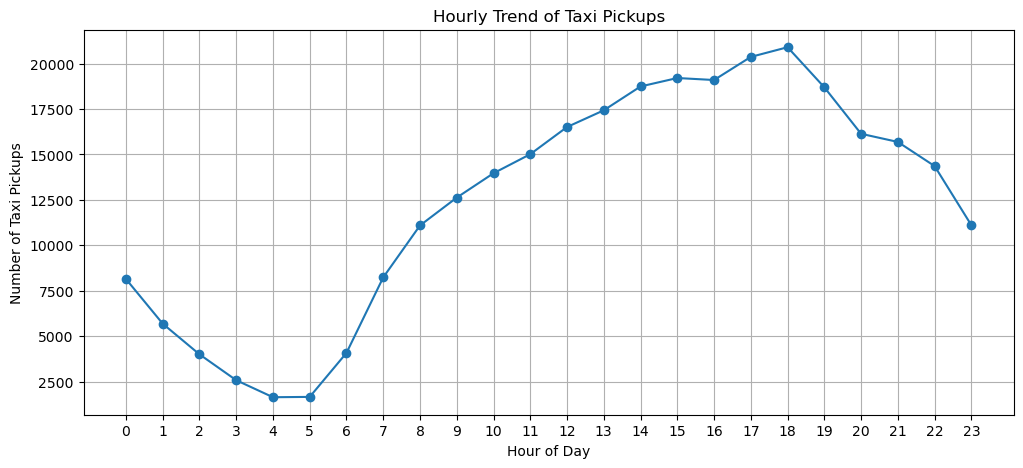

In [363]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
hourly_pickups.plot(kind='line', marker='o')

plt.title('Hourly Trend of Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Taxi Pickups')
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [364]:
hourly_pickups_df = hourly_pickups.reset_index()
hourly_pickups_df.columns = ['pickup_hour', 'pickup_count']

hourly_pickups_df

,pickup_hour,pickup_count
0,0,8148
1,1,5690
2,2,4004
3,3,2580
4,4,1644
5,5,1662
6,6,4082
7,7,8236
8,8,11092
9,9,12624


In [365]:
# Extract day of the week
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()


In [366]:
# Count taxi pickups for each day of the week
daily_pickups = df['pickup_day'].value_counts()

daily_pickups

pickup_day
Tuesday      47616
Saturday     42822
Thursday     42744
Sunday       42124
Friday       42050
Wednesday    40336
Monday       39242
Name: count, dtype: int64

In [370]:
# Arrange days from Monday to Sunday
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_pickups = daily_pickups.reindex(day_order)

daily_pickups

pickup_day
Monday       39242
Tuesday      47616
Wednesday    40336
Thursday     42744
Friday       42050
Saturday     42822
Sunday       42124
Name: count, dtype: int64

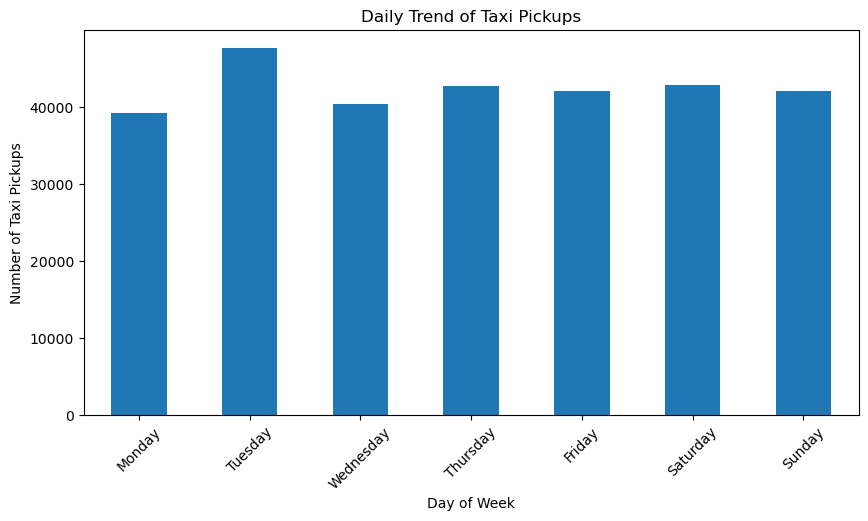

In [373]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
daily_pickups.plot(kind='bar')

plt.title('Daily Trend of Taxi Pickups')
plt.xlabel('Day of Week')
plt.ylabel('Number of Taxi Pickups')
plt.xticks(rotation=45)
plt.show()

In [374]:
# Extract month from pickup datetime
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month


In [377]:
# Count taxi pickups for each month
monthly_pickups = df['pickup_month'].value_counts().sort_index()

monthly_pickups

pickup_month
1     296932
12         2
Name: count, dtype: int64

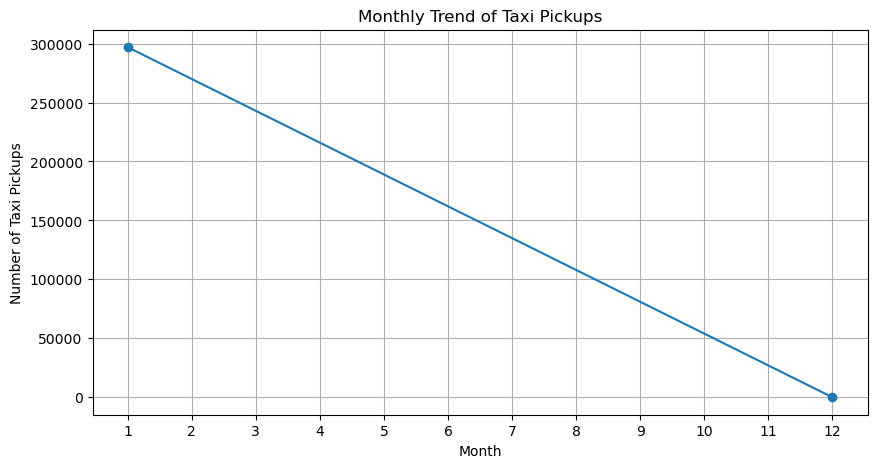

In [378]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
monthly_pickups.plot(kind='line', marker='o')

plt.title('Monthly Trend of Taxi Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Taxi Pickups')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [383]:
# Analyse the financial and trip distance parameters

cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

df[cols].describe().T


,count,mean,std,min,25%,50%,75%,max
fare_amount,296934.0,18.543946,17.192644,0.0,8.60,12.80,19.8000,600.00
tip_amount,296934.0,3.380139,3.854268,0.0,1.00,2.73,4.1475,202.00
total_amount,296934.0,27.313324,21.470567,0.0,15.45,20.12,28.5600,607.55
trip_distance,296934.0,3.363917,4.429868,0.0,1.07,1.78,3.3000,204.10


In [384]:
# Count zero values
(df[cols] == 0).sum()

fare_amount         98
tip_amount       66398
total_amount        60
trip_distance     3740
dtype: int64

In [385]:
# Count negative values
(df[cols] < 0).sum()

fare_amount      0
tip_amount       0
total_amount     0
trip_distance    0
dtype: int64

In [386]:
# Summary of zero and negative values

summary = pd.DataFrame({
    'Zero_values': (df[cols] == 0).sum(),
    'Negative_values': (df[cols] < 0).sum()
})

summary

,Zero_values,Negative_values
fare_amount,98,0
tip_amount,66398,0
total_amount,60,0
trip_distance,3740,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

In [388]:
# Create a copy excluding zero values
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

df_nonzero = df[(df[cols] != 0).all(axis=1)].copy()

df_nonzero.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,trip_duration,pickup_hour,day_of_week,pickup_day,pickup_month
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,15.48,2.5,0.00,0.0,5.083333,0,Sunday,Sunday,1
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,1.0,47.40,2.5,0.00,0.0,33.616667,0,Sunday,Sunday,1
5,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,N,79,164,1,...,1.0,19.68,2.5,0.00,0.0,10.516667,0,Sunday,Sunday,1
6,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,N,79,256,1,...,1.0,30.12,2.5,0.00,0.0,15.883333,0,Sunday,Sunday,1
7,2,2023-01-01 00:44:09,2023-01-01 01:01:17,1.0,7.64,1.0,N,132,95,1,...,1.0,42.54,0.0,1.25,0.0,17.133333,0,Sunday,Sunday,1


In [389]:
df_nonzero[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,229198.0,18.249289,16.363943,3.00,8.6,12.80,19.8000,325.00
tip_amount,229198.0,4.332356,3.756350,0.01,2.3,3.22,4.8075,202.00
total_amount,229198.0,28.065532,21.409682,5.50,16.2,20.64,29.1200,355.07
trip_distance,229198.0,3.350204,4.281844,0.01,1.1,1.80,3.2700,69.54


In [391]:
# Find invalid trips where distance and fare are zero
# but pickup and drop-off zones are different

invalid_trips = df[
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
]

invalid_trips.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,trip_duration,pickup_hour,day_of_week,pickup_day,pickup_month


**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [399]:
# Selected parameters
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

# Create a DataFrame with non-zero entries
df_nonzero = df[(df[cols] != 0).all(axis=1)].copy()

df_nonzero.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee,trip_duration,pickup_hour,day_of_week,pickup_day,pickup_month
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,15.48,2.5,0.00,0.0,5.083333,0,Sunday,Sunday,1
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,1.0,47.40,2.5,0.00,0.0,33.616667,0,Sunday,Sunday,1
5,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,N,79,164,1,...,1.0,19.68,2.5,0.00,0.0,10.516667,0,Sunday,Sunday,1
6,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,N,79,256,1,...,1.0,30.12,2.5,0.00,0.0,15.883333,0,Sunday,Sunday,1
7,2,2023-01-01 00:44:09,2023-01-01 01:01:17,1.0,7.64,1.0,N,132,95,1,...,1.0,42.54,0.0,1.25,0.0,17.133333,0,Sunday,Sunday,1


In [401]:
df_nonzero[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,229198.0,18.249289,16.363943,3.00,8.6,12.80,19.8000,325.00
tip_amount,229198.0,4.332356,3.756350,0.01,2.3,3.22,4.8075,202.00
total_amount,229198.0,28.065532,21.409682,5.50,16.2,20.64,29.1200,355.07
trip_distance,229198.0,3.350204,4.281844,0.01,1.1,1.80,3.2700,69.54


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [404]:
# Extract month
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# Calculate monthly revenue
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()

monthly_revenue


pickup_month
1     8110227.56
12         27.00
Name: total_amount, dtype: float64

In [405]:
monthly_revenue_df = monthly_revenue.reset_index()

monthly_revenue_df.columns = ['Month', 'Total_Revenue']

monthly_revenue_df

,Month,Total_Revenue
0,1,8110227.56
1,12,27.00


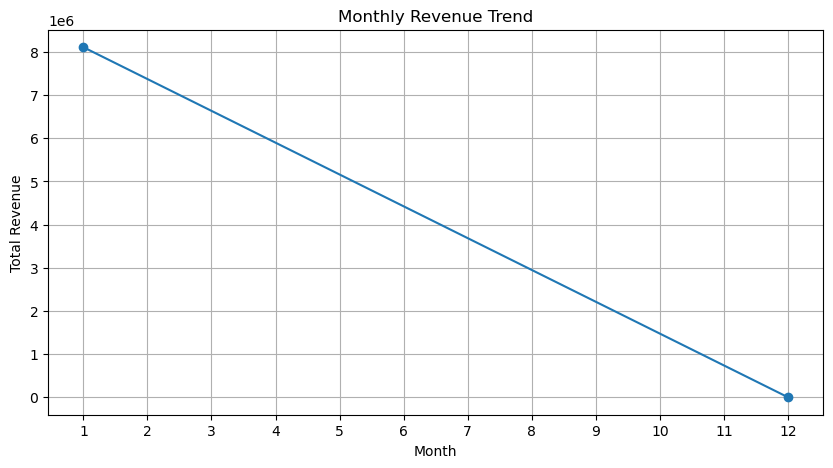

In [406]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [408]:
# Calculate proportion of each quarter



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [412]:
# Show how trip fare is affected by distance
# Create quarter from pickup date
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter

# Calculate revenue for each quarter
quarterly_revenue = df.groupby('quarter')['total_amount'].sum()

# Calculate proportion of total annual revenue
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100

quarterly_proportion


quarter
1    99.999667
4     0.000333
Name: total_amount, dtype: float64

In [415]:
quarterly_proportion_df = quarterly_proportion.reset_index()
quarterly_proportion_df.columns = ['Quarter', 'Revenue_Proportion_Percent']

quarterly_proportion_df

,Quarter,Revenue_Proportion_Percent
0,1,99.999667
1,4,0.000333


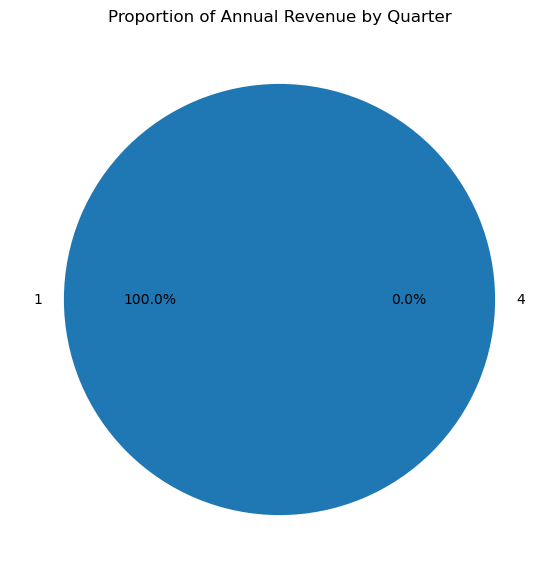

In [417]:
quarterly_proportion.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7)
)

plt.title('Proportion of Annual Revenue by Quarter')
plt.ylabel('')
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [420]:
# Calculate trip duration in minutes
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

df['trip_duration'].describe()

count    296934.000000
mean         15.518254
std          40.832264
min           0.000000
25%           7.083333
50%          11.433333
75%          18.150000
max        3040.516667
Name: trip_duration, dtype: float64

In [421]:
# Calculate correlations
corr1 = df['fare_amount'].corr(df['trip_duration'])
corr2 = df['fare_amount'].corr(df['passenger_count'])
corr3 = df['tip_amount'].corr(df['trip_distance'])

print("Correlation between fare_amount and trip_duration:", corr1)
print("Correlation between fare_amount and passenger_count:", corr2)
print("Correlation between tip_amount and trip_distance:", corr3)

Correlation between fare_amount and trip_duration: 0.2289912113588804
Correlation between fare_amount and passenger_count: 0.0325402216789338
Correlation between tip_amount and trip_distance: 0.570867561535841


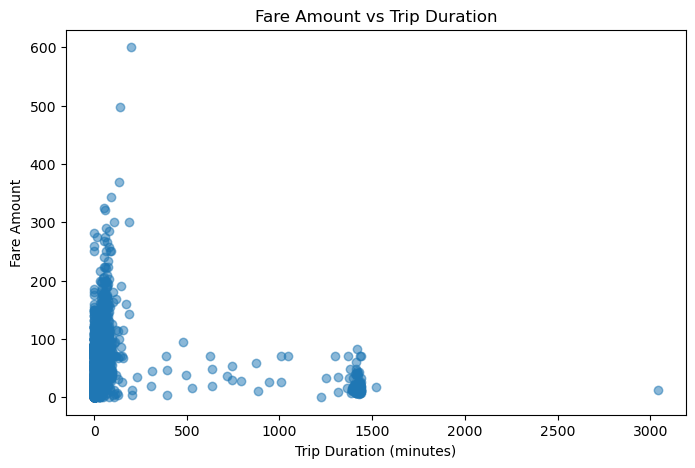

In [423]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['trip_duration'], df['fare_amount'], alpha=0.3)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Trip Duration')
plt.show()

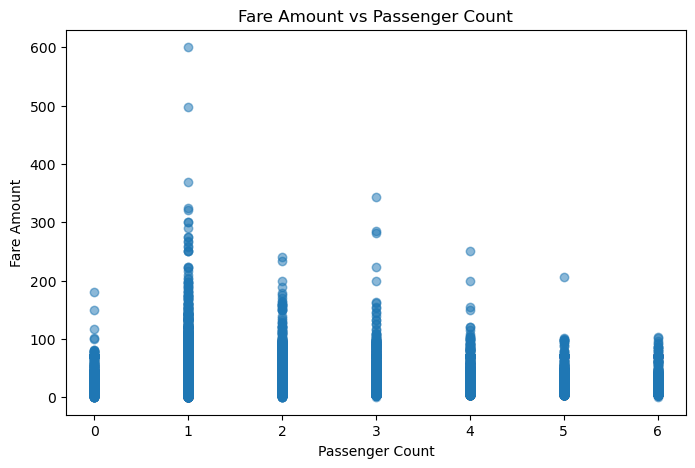

In [425]:
plt.figure(figsize=(8, 5))
plt.scatter(df['passenger_count'], df['fare_amount'], alpha=0.3)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Passenger Count')
plt.show()

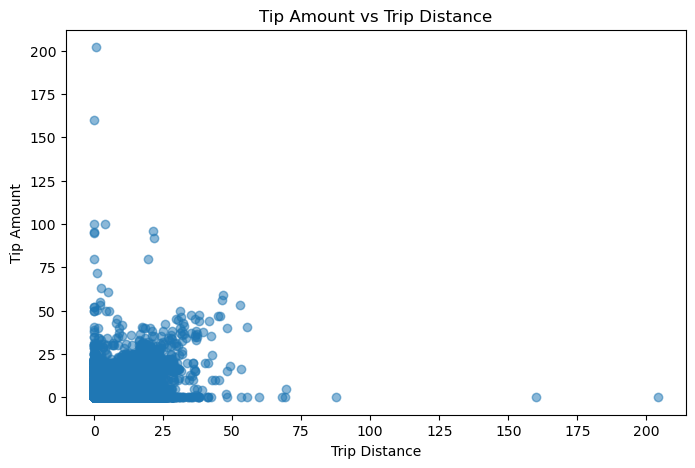

In [426]:
plt.figure(figsize=(8, 5))
plt.scatter(df['trip_distance'], df['tip_amount'], alpha=0.3)
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip Amount vs Trip Distance')
plt.show()

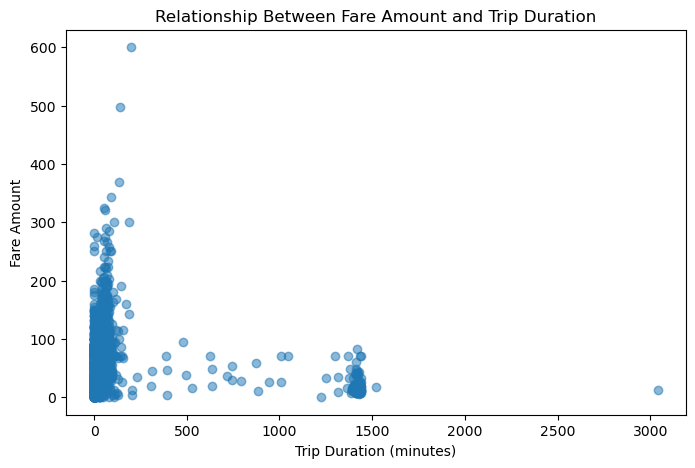

In [427]:
# Show relationship between fare and trip duration
# Show relationship between fare and trip duration

plt.figure(figsize=(8, 5))

plt.scatter(
    df['trip_duration'],
    df['fare_amount'],
    alpha=0.3
)

plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.title('Relationship Between Fare Amount and Trip Duration')

plt.show()


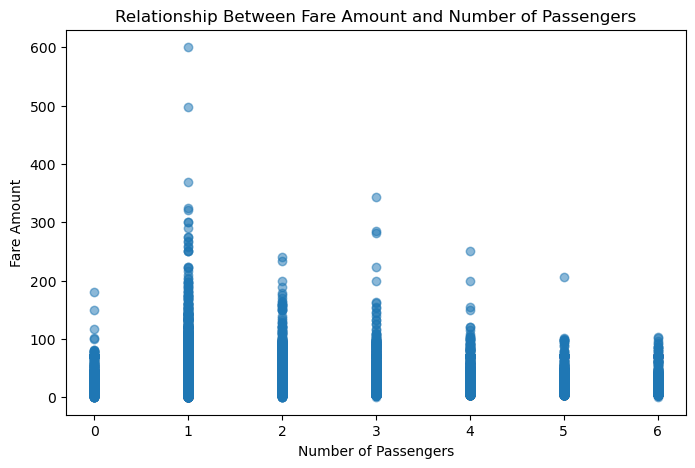

In [429]:
# Show relationship between fare and number of passengers

# Show relationship between fare and number of passengers

plt.figure(figsize=(8, 5))

plt.scatter(
    df['passenger_count'],
    df['fare_amount'],
    alpha=0.3
)

plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount')
plt.title('Relationship Between Fare Amount and Number of Passengers')

plt.show()

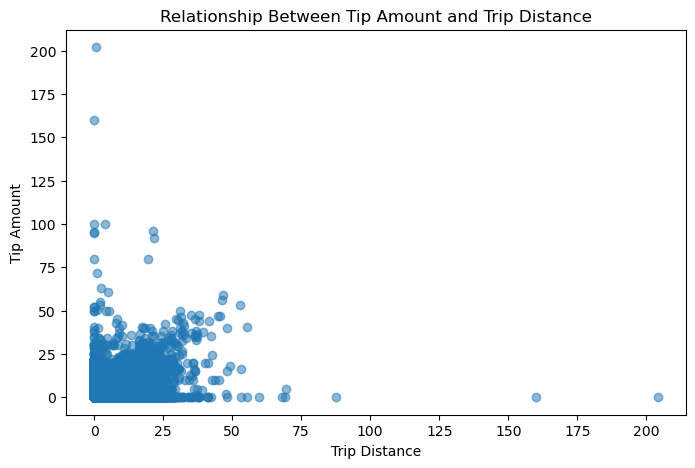

In [430]:
# Show relationship between tip and trip distance
# Show relationship between tip and trip distance

plt.figure(figsize=(8, 5))

plt.scatter(
    df['trip_distance'],
    df['tip_amount'],
    alpha=0.3
)

plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Relationship Between Tip Amount and Trip Distance')

plt.show()


Correlation: 0.570867561535841


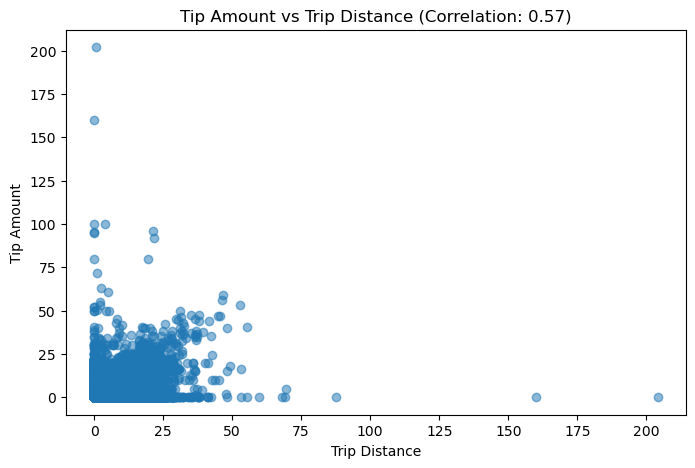

In [431]:
correlation = df['tip_amount'].corr(df['trip_distance'])

print("Correlation:", correlation)

plt.figure(figsize=(8, 5))
plt.scatter(df['trip_distance'], df['tip_amount'], alpha=0.3)

plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title(f'Tip Amount vs Trip Distance (Correlation: {correlation:.2f})')

plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [433]:
# Count different payment types

payment_counts = df['payment_type'].value_counts()

payment_counts

payment_type
1    240920
2     52810
4      1786
3      1418
Name: count, dtype: int64

In [434]:
# Calculate percentage distribution

payment_percentage = df['payment_type'].value_counts(normalize=True) * 100

payment_percentage

payment_type
1    81.135875
2    17.785097
4     0.601480
3     0.477547
Name: proportion, dtype: float64

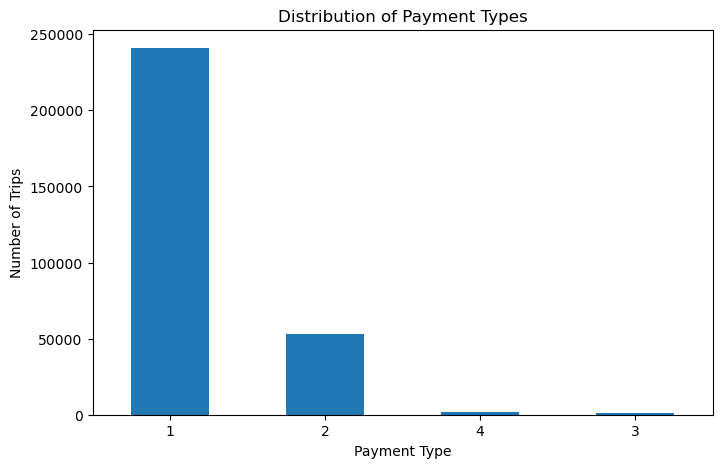

In [436]:
# Visualise payment type distribution

plt.figure(figsize=(8, 5))

payment_counts.plot(kind='bar')

plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')

plt.xticks(rotation=0)
plt.show()

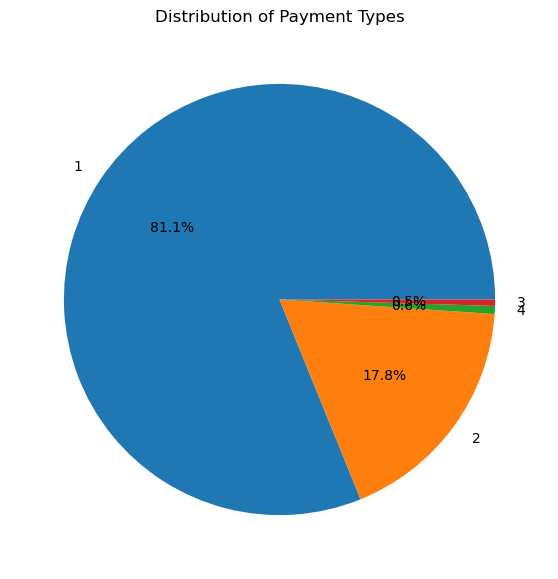

In [437]:
plt.figure(figsize=(7, 7))

payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribution of Payment Types')
plt.ylabel('')

plt.show()

In [439]:
# Analyse the distribution of different payment types

payment_counts = df['payment_type'].value_counts()
payment_counts



payment_type
1    240920
2     52810
4      1786
3      1418
Name: count, dtype: int64

In [440]:
payment_percentage = df['payment_type'].value_counts(normalize=True) * 100
payment_percentage

payment_type
1    81.135875
2    17.785097
4     0.601480
3     0.477547
Name: proportion, dtype: float64

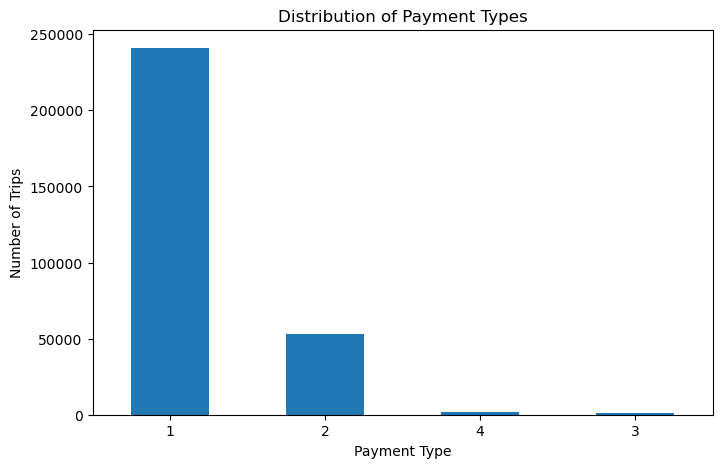

In [442]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

payment_counts.plot(kind='bar')

plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')
plt.xticks(rotation=0)

plt.show()

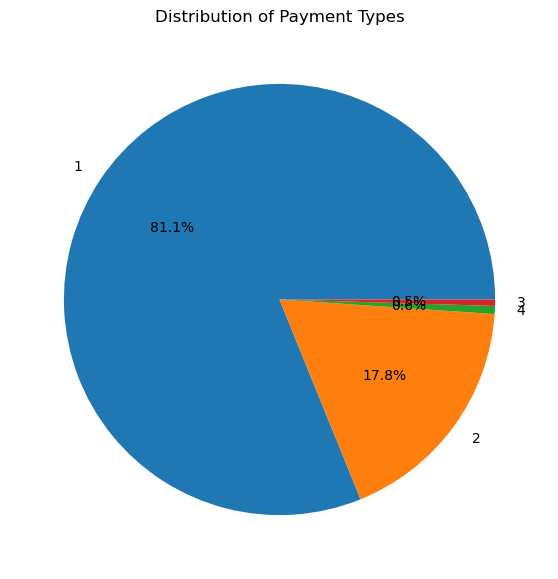

In [443]:
plt.figure(figsize=(7, 7))

payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribution of Payment Types')
plt.ylabel('')

plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [450]:
%pip install geopandas

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [452]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [453]:
import sys
!{sys.executable} -m pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [454]:
import geopandas as gpd
print(gpd.__version__)

1.1.4


In [463]:
# Source - https://stackoverflow.com/a/76549743
# Posted by Timeless, modified by community. See post 'Timeline' for change history
# Retrieved 2026-09-24, License - CC BY-SA 4.0

import geopandas as gpd

url = ""E:\Upgrade files\683eb526-56d0-483e-b940-287fbdee518c-APAGAI-Assignment-EDA\APAGAI - Assignment - EDA\Datasets and Dictionary\taxi_zones\taxi_zones.dbf"

gdf = gpd.read_file(url)


SyntaxError: invalid syntax (2263401187.py, line 7)

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd


# Read the shapefile using geopandas
#zones = # read the .shp file using gpd


zones = gpd.read_file(r'C:\Users\Admin\NYC\taxi_zones\taxi_zones.shp')
zones.head()
print(zones)


In [ ]:
print(zones.info())
zones.plot()

In [ ]:
import matplotlib.pyplot as plt

zones.plot(figsize=(12, 10))

plt.title('NYC Taxi Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
zones.columns

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
pickup_zones = zones[['LocationID', 'zone', 'borough', 'geometry']].copy()

df_pickup = df.merge(
    pickup_zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df_pickup.head()


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
# Total number of trips per pickup location ID

trips_per_location = df.groupby('PULocationID').size().reset_index(name='total_trips')

trips_per_location.head()



In [467]:
trips_per_location = trips_per_location.sort_values(
    'total_trips',
    ascending=False
)


trips_per_location.head(10)
print(trips_per_location)

     PULocationID  total_trips
110           132        15658
208           237        14338
207           236        13520
137           161        13506
159           186        10688
..            ...          ...
165           192            2
167           194            2
25             31            2
211           240            2
87            101            2

[235 rows x 2 columns]


In [469]:
trips_per_location = (
    df.groupby('PULocationID')
      .size()
      .reset_index(name='total_trips')
)

trips_per_location.head()

,PULocationID,total_trips
0,1,30
1,3,12
2,4,292
3,6,12
4,7,132


In [471]:
zones = gpd.read_file(
    r"E:\Upgrade files\683eb526-56d0-483e-b940-287fbdee518c-APAGAI-Assignment-EDA\APAGAI - Assignment - EDA\Datasets and Dictionary\taxi_zones"
)

zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [472]:
zones_trips = zones.merge(
    trips_per_location,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

zones_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,30.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,12.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,292.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN


In [473]:
zones_trips['total_trips'] = zones_trips['total_trips'].fillna(0)

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [478]:
# Merge trip counts back to the zones GeoDataFrame

zones_trips = zones.merge(
    trips_per_location,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

zones_trips.head()



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,30.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,12.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,292.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN


In [480]:
zones_trips[['LocationID', 'zone', 'borough', 'total_trips']].head()

,LocationID,zone,borough,total_trips
0,1,Newark Airport,EWR,30.0
1,2,Jamaica Bay,Queens,NaN
2,3,Allerton/Pelham Gardens,Bronx,12.0
3,4,Alphabet City,Manhattan,292.0
4,5,Arden Heights,Staten Island,NaN


In [482]:
zones_trips['total_trips'] = zones_trips['total_trips'].fillna(0)

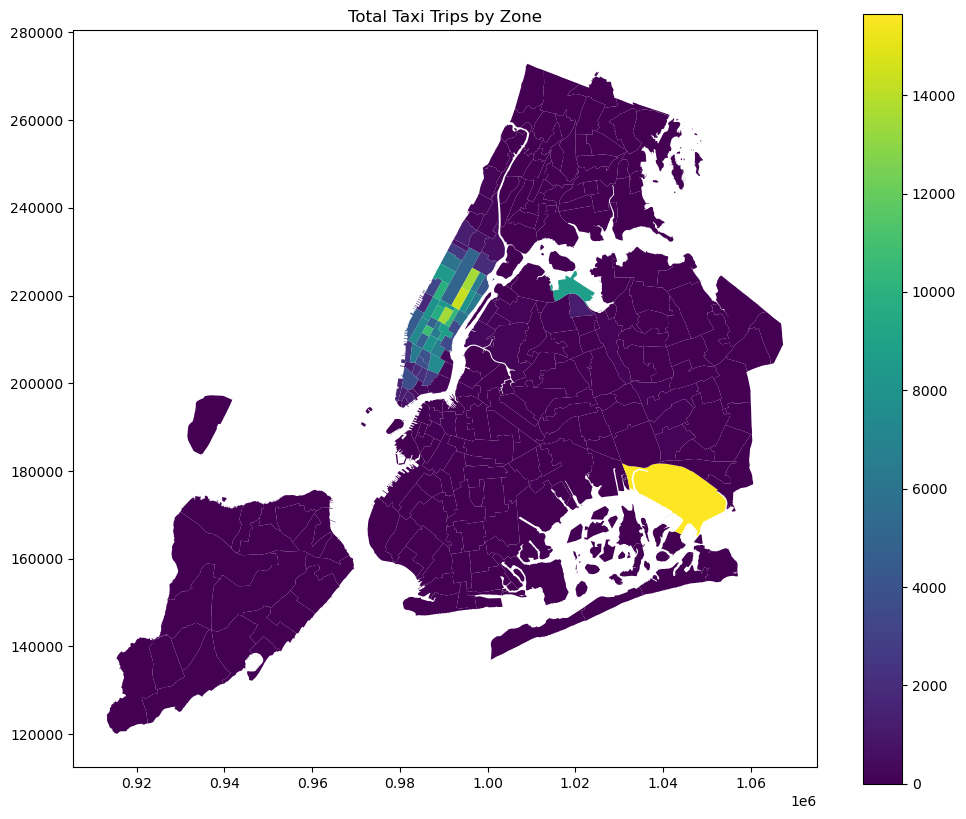

In [484]:
zones_trips.plot(
    column='total_trips',
    figsize=(12, 10),
    legend=True
)

plt.title('Total Taxi Trips by Zone')
plt.show()

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

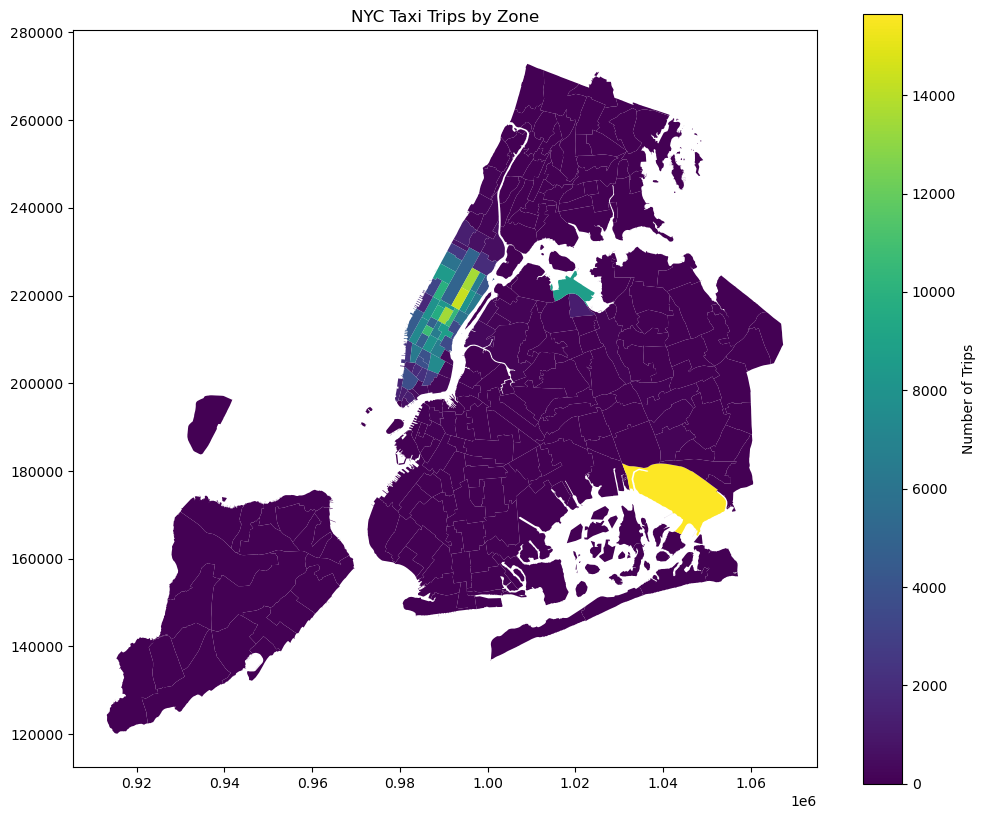

In [487]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_trips.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'vertical'
    }
)

ax.set_title('NYC Taxi Trips by Zone')
plt.show()

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

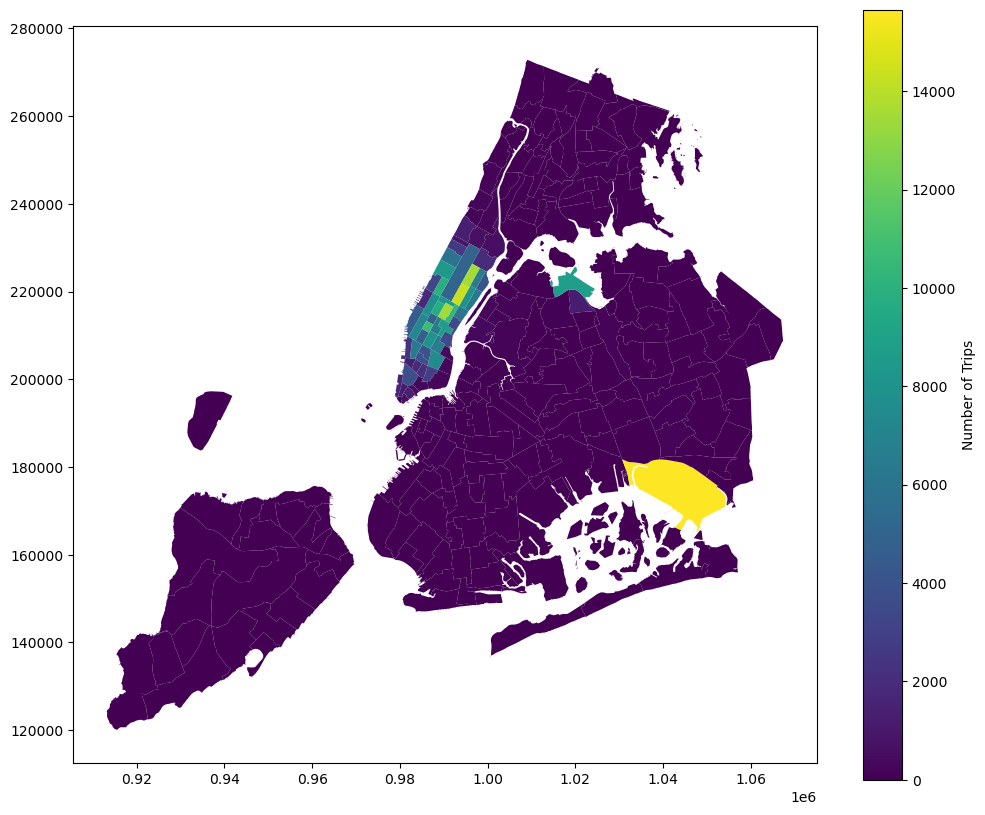

In [489]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))


# Plot the map and display it

# Plot color-coded map
zones_trips.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'vertical'
    }
)

plt.show()




In [491]:
# Sort zones by number of trips
zones_trips_sorted = zones_trips.sort_values(
    'total_trips',
    ascending=False
)

# Display the sorted DataFrame
zones_trips_sorted[
    ['LocationID', 'zone', 'borough', 'total_trips']
].head(20)


,LocationID,zone,borough,total_trips
131,132,JFK Airport,Queens,15658.0
236,237,Upper East Side South,Manhattan,14338.0
235,236,Upper East Side North,Manhattan,13520.0
160,161,Midtown Center,Manhattan,13506.0
185,186,Penn Station/Madison Sq West,Manhattan,10688.0
161,162,Midtown East,Manhattan,10364.0
141,142,Lincoln Square East,Manhattan,9938.0
229,230,Times Sq/Theatre District,Manhattan,9608.0
137,138,LaGuardia Airport,Queens,8704.0
169,170,Murray Hill,Manhattan,8638.0


In [492]:
zones_trips_sorted[
    ['LocationID', 'zone', 'borough', 'total_trips']
]

,LocationID,zone,borough,total_trips
131,132,JFK Airport,Queens,15658.0
236,237,Upper East Side South,Manhattan,14338.0
235,236,Upper East Side North,Manhattan,13520.0
160,161,Midtown Center,Manhattan,13506.0
185,186,Penn Station/Madison Sq West,Manhattan,10688.0
...,...,...,...,...
127,128,Inwood Hill Park,Manhattan,0.0
1,2,Jamaica Bay,Queens,0.0
171,172,New Dorp/Midland Beach,Staten Island,0.0
4,5,Arden Heights,Staten Island,0.0


In [493]:
zones_trips.sort_values('total_trips', ascending=False).head(20)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,total_trips
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,15658.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,14338.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,13520.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,13506.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",186.0,10688.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,10364.0
141,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21...",142.0,9938.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",230.0,9608.0
137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",138.0,8704.0
169,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",170.0,8638.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

In [503]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [507]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [508]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [510]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [511]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [514]:
hourly_duration = (
    df.groupby('pickup_hour')['trip_duration']
      .mean()
      .sort_index()
)

hourly_duration

pickup_hour
0     14.942681
1     14.680697
2     15.304953
3     15.703437
4     20.476622
5     16.181147
6     14.433162
7     14.966703
8     14.755217
9     15.363968
10    14.858367
11    14.520761
12    14.852092
13    15.840862
14    17.942296
15    17.013973
16    17.698039
17    16.827180
18    15.077603
19    13.809297
20    14.347948
21    14.299284
22    14.640228
23    15.416327
Name: trip_duration, dtype: float64

In [519]:
hourly_duration

pickup_hour
0     14.942681
1     14.680697
2     15.304953
3     15.703437
4     20.476622
5     16.181147
6     14.433162
7     14.966703
8     14.755217
9     15.363968
10    14.858367
11    14.520761
12    14.852092
13    15.840862
14    17.942296
15    17.013973
16    17.698039
17    16.827180
18    15.077603
19    13.809297
20    14.347948
21    14.299284
22    14.640228
23    15.416327
Name: trip_duration, dtype: float64

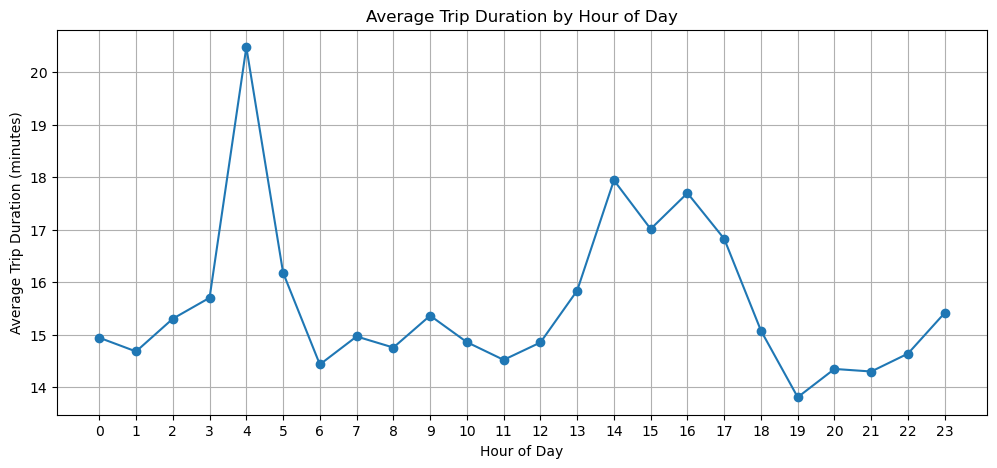

In [520]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

hourly_duration.plot(kind='line', marker='o')

plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Duration (minutes)')
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [522]:
hourly_duration.sort_values(ascending=False).head(10)

pickup_hour
4     20.476622
14    17.942296
16    17.698039
15    17.013973
17    16.827180
5     16.181147
13    15.840862
3     15.703437
23    15.416327
9     15.363968
Name: trip_duration, dtype: float64

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

In [526]:
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [527]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [530]:
route_data = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration'] > 0)
].copy()

In [531]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [532]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [536]:
route_hour = (
    route_data
    .groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
    .agg(
        average_distance=('trip_distance', 'mean'),
        average_duration=('trip_duration', 'mean'),
        trip_count=('trip_duration', 'size')
    )
    .reset_index()
)

In [537]:
route_hour.head()

,PULocationID,DOLocationID,pickup_hour,average_distance,average_duration,trip_count
0,1,1,17,0.04,0.066667,2
1,3,32,17,0.40,6.533333,2
2,3,69,10,6.00,56.700000,2
3,3,167,13,3.90,51.516667,2
4,4,1,2,19.69,44.300000,2


In [538]:
zone_names = zones[['LocationID', 'zone', 'borough']].copy()

pickup_names = zone_names.rename(
    columns={
        'LocationID': 'PULocationID',
        'zone': 'pickup_zone',
        'borough': 'pickup_borough'
    }
)

dropoff_names = zone_names.rename(
    columns={
        'LocationID': 'DOLocationID',
        'zone': 'dropoff_zone',
        'borough': 'dropoff_borough'
    }
)

In [539]:
# Step 1: Create pickup hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Step 2: Create trip duration in minutes
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Step 3: Keep valid routes
route_data = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration'] > 0)
].copy()

# Step 4: Calculate route statistics by hour
route_hour = (
    route_data
    .groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
    .agg(
        average_distance=('trip_distance', 'mean'),
        average_duration=('trip_duration', 'mean'),
        trip_count=('trip_duration', 'size')
    )
    .reset_index()
)

# Step 5: Calculate speed in miles per hour
route_hour['speed_mph'] = (
    route_hour['average_distance'] /
    route_hour['average_duration']
) * 60

# Step 6: Find slowest routes
slowest_routes = (
    route_hour[route_hour['trip_count'] >= 10]
    .sort_values('speed_mph', ascending=True)
)

# Step 7: Display slowest routes
slowest_routes[
    [
        'PULocationID',
        'DOLocationID',
        'pickup_hour',
        'average_distance',
        'average_duration',
        'speed_mph',
        'trip_count'
    ]
].head(20)

,PULocationID,DOLocationID,pickup_hour,average_distance,average_duration,speed_mph,trip_count
34572,230,48,23,0.670000,181.529167,0.221452,16
7070,79,144,22,1.020000,243.458333,0.251378,12
43736,249,231,1,1.358000,290.966667,0.280032,10
24916,158,211,14,1.452000,295.970000,0.294354,10
2494,48,48,13,0.619231,113.341026,0.327806,26
4687,68,142,9,1.718000,291.316667,0.353842,10
11009,107,162,12,1.734000,281.593333,0.369469,10
13084,114,249,18,0.839091,135.639394,0.371171,22
45650,263,162,13,1.876000,293.213333,0.383884,10
41002,238,238,14,0.598750,93.109375,0.385837,32


In [540]:
route_hour['speed_mph'] = route_hour['speed'] * 60

KeyError: 'speed'

In [ ]:
slowest_routes = (
    route_hour[route_hour['trip_count'] >= 10]
    .sort_values('speed_mph', ascending=True)
)

slowest_routes.head(20)

In [ ]:
slowest_routes[
    [
        'PULocationID',
        'DOLocationID',
        'pickup_hour',
        'average_distance',
        'average_duration',
        'speed_mph',
        'trip_count'
    ]
].head(20)

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day
zone_names = zones[['LocationID', 'zone', 'borough']].copy()

pickup_names = zone_names.rename(
    columns={
        'LocationID': 'PULocationID',
        'zone': 'pickup_zone',
        'borough': 'pickup_borough'
    }
)

dropoff_names = zone_names.rename(
    columns={
        'LocationID': 'DOLocationID',
        'zone': 'dropoff_zone',
        'borough': 'dropoff_borough'
    }
)

slowest_routes_named = (
    slowest_routes
    .merge(pickup_names, on='PULocationID', how='left')
    .merge(dropoff_names, on='DOLocationID', how='left')
)


In [ ]:
slowest_routes_named[
    [
        'pickup_zone',
        'dropoff_zone',
        'pickup_hour',
        'average_distance',
        'average_duration',
        'speed_mph',
        'trip_count'
    ]
].head(20)

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour

import matplotlib.pyplot as plt

# Calculate trips for each hour
hourly_trips = (
    df['tpep_pickup_datetime']
    .dt.hour
    .value_counts()
    .sort_index()
)

# Find busiest hour
busiest_hour = hourly_trips.idxmax()
busiest_trips = hourly_trips.max()

# Visualise
plt.figure(figsize=(12, 5))
hourly_trips.plot(kind='line', marker='o')

plt.title('Number of Taxi Trips per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.grid(True)

plt.show()

# Display busiest hour
print(f"Busiest hour: {busiest_hour}:00")
print(f"Number of trips: {busiest_trips:,}")


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
#sample_fraction =
# Scale up the number of trips

# Sampling fraction used earlier
sample_fraction = 0.05

# Scale up the hourly trip counts
actual_hourly_trips = hourly_trips / sample_fraction

# Find the actual busiest hour
actual_busiest_hour = actual_hourly_trips.idxmax()
actual_busiest_trips = actual_hourly_trips.max()

print("Actual busiest hour:", actual_busiest_hour)
print("Estimated actual number of trips:", round(actual_busiest_trips))


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for weekdays and weekends

import matplotlib.pyplot as plt

# Create day of week and hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Define weekdays and weekends
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekends = ['Saturday', 'Sunday']

# Calculate hourly trips
weekday_trips = (
    df[df['day_of_week'].isin(weekdays)]
    .groupby('pickup_hour')
    .size()
)

weekend_trips = (
    df[df['day_of_week'].isin(weekends)]
    .groupby('pickup_hour')
    .size()
)

# Plot comparison
plt.figure(figsize=(12, 5))

plt.plot(
    weekday_trips.index,
    weekday_trips.values,
    marker='o',
    label='Weekdays'
)

plt.plot(
    weekend_trips.index,
    weekend_trips.values,
    marker='o',
    label='Weekends'
)

plt.title('Hourly Traffic Pattern: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [552]:
# Find top 10 pickup zones

top_10_pickup_zones = (
    df['PULocationID']
    .value_counts()
    .head(10)
)

top_10_pickup_zones


PULocationID
132    15658
237    14338
236    13520
161    13506
186    10688
162    10364
142     9938
230     9608
138     8704
170     8638
Name: count, dtype: int64

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [554]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Count pickups and dropoffs by zone
pickup_counts = df['PULocationID'].value_counts()
dropoff_counts = df['DOLocationID'].value_counts()

# Combine pickup and dropoff counts
zone_ratios = pd.DataFrame({
    'pickup_count': pickup_counts,
    'dropoff_count': dropoff_counts
}).fillna(0)

# Calculate pickup/dropoff ratio
zone_ratios['pickup_dropoff_ratio'] = (
    zone_ratios['pickup_count'] /
    zone_ratios['dropoff_count'].replace(0, pd.NA)
)

# Top 10 ratios
top_10_ratios = zone_ratios.sort_values(
    'pickup_dropoff_ratio',
    ascending=False
).head(10)

# Bottom 10 ratios
bottom_10_ratios = zone_ratios.sort_values(
    'pickup_dropoff_ratio',
    ascending=True
).head(10)

print("Top 10 Pickup/Dropoff Ratios")
display(top_10_ratios)

print("\nBottom 10 Pickup/Dropoff Ratios")
display(bottom_10_ratios)


Top 10 Pickup/Dropoff Ratios


,pickup_count,dropoff_count,pickup_dropoff_ratio
70,1262.0,162.0,7.790123
132,15658.0,3016.0,5.191645
138,8704.0,3094.0,2.813187
264,4004.0,2230.0,1.795516
186,10688.0,6606.0,1.617923
214,6.0,4.0,1.5
6,12.0,8.0,1.5
206,6.0,4.0,1.5
43,5002.0,3546.0,1.410603
114,3800.0,2750.0,1.381818



Bottom 10 Pickup/Dropoff Ratios


,pickup_count,dropoff_count,pickup_dropoff_ratio
46,0.0,6.0,0.0
221,0.0,8.0,0.0
128,0.0,14.0,0.0
27,0.0,2.0,0.0
115,0.0,4.0,0.0
241,0.0,66.0,0.0
172,0.0,2.0,0.0
30,0.0,2.0,0.0
245,0.0,6.0,0.0
67,0.0,40.0,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [556]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Night hours: 11 PM to 5 AM
# 23 = 11 PM, 0 = 12 AM, 1 = 1 AM, ..., 4 = 4 AM

night_hours = [23, 0, 1, 2, 3, 4]

# Create pickup and dropoff hours
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour

# Filter ONLY night-hour trips
night_pickups = df[df['pickup_hour'].isin(night_hours)]
night_dropoffs = df[df['dropoff_hour'].isin(night_hours)]

# -------------------------------
# Top 10 NIGHT pickup zones
# -------------------------------

top_10_night_pickup = (
    night_pickups['PULocationID']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_night_pickup.columns = [
    'LocationID',
    'night_pickup_count'
]

top_10_night_pickup = top_10_night_pickup.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID',
    how='left'
)

# -------------------------------
# Top 10 NIGHT dropoff zones
# -------------------------------

top_10_night_dropoff = (
    night_dropoffs['DOLocationID']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_night_dropoff.columns = [
    'LocationID',
    'night_dropoff_count'
]

top_10_night_dropoff = top_10_night_dropoff.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID',
    how='left'
)

# Display results
print("Top 10 Pickup Zones During Night Hours (11 PM - 5 AM)")
display(top_10_night_pickup)

print("Top 10 Dropoff Zones During Night Hours (11 PM - 5 AM)")
display(top_10_night_dropoff)

Top 10 Pickup Zones During Night Hours (11 PM - 5 AM)


,LocationID,night_pickup_count,zone,borough
0,79,2752,East Village,Manhattan
1,249,1896,West Village,Manhattan
2,132,1896,JFK Airport,Queens
3,48,1572,Clinton East,Manhattan
4,148,1526,Lower East Side,Manhattan
5,114,1364,Greenwich Village South,Manhattan
6,230,1172,Times Sq/Theatre District,Manhattan
7,138,972,LaGuardia Airport,Queens
8,107,972,Gramercy,Manhattan
9,186,934,Penn Station/Madison Sq West,Manhattan


Top 10 Dropoff Zones During Night Hours (11 PM - 5 AM)


,LocationID,night_dropoff_count,zone,borough
0,79,1406,East Village,Manhattan
1,48,1218,Clinton East,Manhattan
2,170,1018,Murray Hill,Manhattan
3,107,934,Gramercy,Manhattan
4,141,924,Lenox Hill West,Manhattan
5,263,908,Yorkville West,Manhattan
6,68,880,East Chelsea,Manhattan
7,249,812,West Village,Manhattan
8,229,784,Sutton Place/Turtle Bay North,Manhattan
9,239,774,Upper West Side South,Manhattan


In [557]:
night_pickups['PULocationID'].value_counts().head(10)

PULocationID
79     2752
249    1896
132    1896
48     1572
148    1526
114    1364
230    1172
138     972
107     972
186     934
Name: count, dtype: int64

In [560]:
night_dropoffs['DOLocationID'].value_counts().head(10)

DOLocationID
79     1406
48     1218
170    1018
107     934
141     924
263     908
68      880
249     812
229     784
239     774
Name: count, dtype: int64

In [562]:
df['PULocationID'].value_counts().head(10)

PULocationID
132    15658
237    14338
236    13520
161    13506
186    10688
162    10364
142     9938
230     9608
138     8704
170     8638
Name: count, dtype: int64

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [565]:
night_pickups = df[df['pickup_hour'].isin(night_hours)].copy()

night_dropoffs = df[df['dropoff_hour'].isin(night_hours)].copy()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [567]:
# Analyse fare per mile per passenger for different passenger counts

# Keep valid trips only
fare_data = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['passenger_count'] > 0)
].copy()

# Calculate fare per mile for each trip
fare_data['fare_per_mile'] = (
    fare_data['fare_amount'] / fare_data['trip_distance']
)

# Average fare per mile for each passenger count
avg_fare_per_mile = (
    fare_data
    .groupby('passenger_count')['fare_per_mile']
    .mean()
)

# Divide by passenger count
fare_per_mile_per_passenger = (
    avg_fare_per_mile / avg_fare_per_mile.index
)

# Display result
result = pd.DataFrame({
    'Passenger_Count': fare_per_mile_per_passenger.index,
    'Average_Fare_Per_Mile': avg_fare_per_mile.values,
    'Fare_Per_Mile_Per_Passenger': fare_per_mile_per_passenger.values
})

result



,Passenger_Count,Average_Fare_Per_Mile,Fare_Per_Mile_Per_Passenger
0,1.0,10.168073,10.168073
1,2.0,11.560636,5.780318
2,3.0,8.380471,2.793490
3,4.0,13.829276,3.457319
4,5.0,7.742114,1.548423
5,6.0,7.711148,1.285191


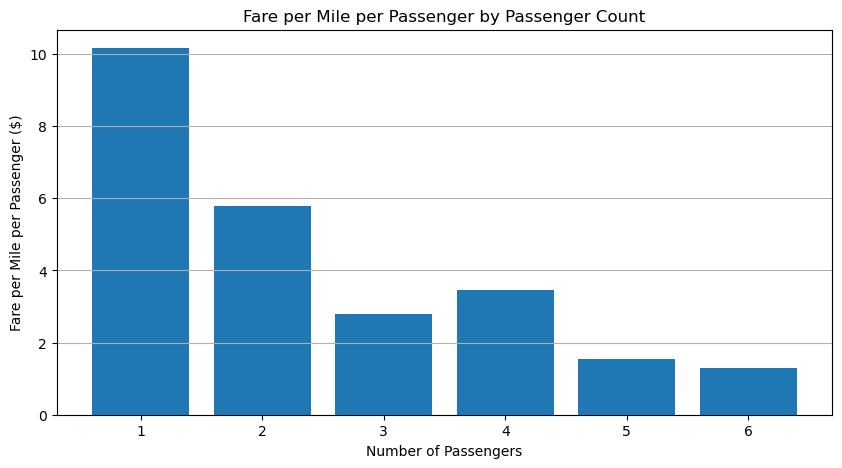

In [568]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    result['Passenger_Count'],
    result['Fare_Per_Mile_Per_Passenger']
)

plt.title('Fare per Mile per Passenger by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare per Mile per Passenger ($)')
plt.xticks(result['Passenger_Count'])
plt.grid(axis='y')

plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [574]:
# Compare the average fare per mile for different days and different times of the day

# Keep only valid trips
valid_data = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0)
].copy()

# Calculate fare per mile
valid_data['fare_per_mile'] = (
    valid_data['fare_amount'] / valid_data['trip_distance']
)

# -----------------------------
# Average fare per mile by day
# -----------------------------

valid_data['day_of_week'] = (
    valid_data['tpep_pickup_datetime'].dt.day_name()
)

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_avg = (
    valid_data
    .groupby('day_of_week')['fare_per_mile']
    .mean()
    .reindex(day_order)
)

print("Average Fare per Mile by Day:")
display(daily_avg)

# -----------------------------
# Average fare per mile by hour
# -----------------------------

valid_data['pickup_hour'] = (
    valid_data['tpep_pickup_datetime'].dt.hour
)

hourly_avg = (
    valid_data
    .groupby('pickup_hour')['fare_per_mile']
    .mean()
    .sort_index()
)

print("Average Fare per Mile by Hour:")
display(hourly_avg)


Average Fare per Mile by Day:


day_of_week
Monday       10.140535
Tuesday      10.490533
Wednesday    10.136814
Thursday     10.367241
Friday        9.788564
Saturday      9.533752
Sunday       11.571145
Name: fare_per_mile, dtype: float64

Average Fare per Mile by Hour:


pickup_hour
0      7.433829
1     12.669153
2      9.203728
3      7.367290
4      7.529072
5     10.967668
6      6.822705
7      7.688428
8     11.094287
9     10.189961
10    10.021227
11     9.630150
12     9.941826
13    11.790049
14    10.155962
15    12.379405
16    14.406735
17    10.547346
18    10.061345
19    12.060073
20     8.361317
21     8.507585
22     8.695867
23     8.473912
Name: fare_per_mile, dtype: float64

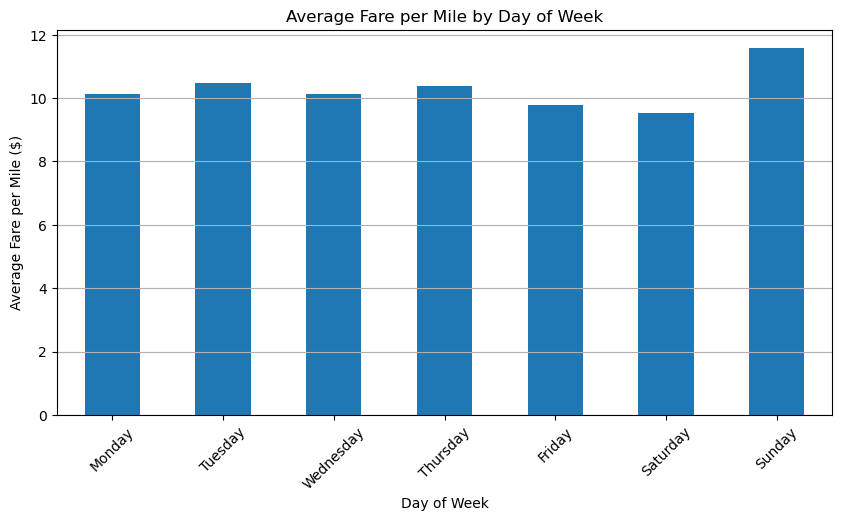

In [578]:
plt.figure(figsize=(10, 5))

daily_avg.plot(kind='bar')

plt.title('Average Fare per Mile by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [581]:
print("Highest daily average:",
      daily_avg.idxmax(),
      "=", round(daily_avg.max(), 2))

print("Lowest daily average:",
      daily_avg.idxmin(),
      "=", round(daily_avg.min(), 2))

print("Highest hourly average:",
      hourly_avg.idxmax(),
      "=", round(hourly_avg.max(), 2))

print("Lowest hourly average:",
      hourly_avg.idxmin(),
      "=", round(hourly_avg.min(), 2))

Highest daily average: Sunday = 11.57
Lowest daily average: Saturday = 9.53
Highest hourly average: 16 = 14.41
Lowest hourly average: 6 = 6.82


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [583]:
     # Compare fare per mile for different vendors

# Keep only valid trips
vendor_data = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0)
].copy()

# Calculate fare per mile
vendor_data['fare_per_mile'] = (
    vendor_data['fare_amount'] / vendor_data['trip_distance']
)

# Calculate average fare per mile for each vendor
vendor_fare_per_mile = (
    vendor_data
    .groupby('VendorID')['fare_per_mile']
    .mean()
    .sort_values(ascending=False)
)

print("Average Fare per Mile by Vendor:")
display(vendor_fare_per_mile)


Average Fare per Mile by Vendor:


VendorID
2    11.297174
1     7.627302
Name: fare_per_mile, dtype: float64

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


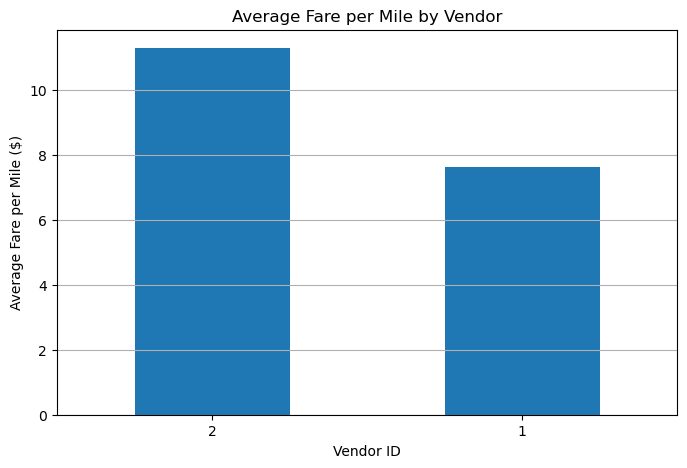

In [585]:
plt.figure(figsize=(8, 5))

vendor_fare_per_mile.plot(kind='bar')

plt.title('Average Fare per Mile by Vendor')
plt.xlabel('Vendor ID')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [589]:
vendor_comparison = vendor_fare_per_mile.reset_index()

vendor_comparison.columns = [
    'VendorID',
    'Average_Fare_Per_Mile'
]

vendor_comparison

,VendorID,Average_Fare_Per_Mile
0,2,11.297174
1,1,7.627302


In [593]:
# Defining distance tiers

bins = [0, 2, 5, 10, 20, float('inf')]

labels = [
    '0-2 miles',
    '2-5 miles',
    '5-10 miles',
    '10-20 miles',
    '20+ miles'
]

df['distance_tier'] = pd.cut(
    df['trip_distance'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Check the distribution
df['distance_tier'].value_counts().sort_index()


distance_tier
0-2 miles      166708
2-5 miles       81694
5-10 miles      24710
10-20 miles     20780
20+ miles        3042
Name: count, dtype: int64

##### Customer Experience and Other Factors

In [595]:
df[['trip_distance', 'distance_tier']].head(10)

,trip_distance,distance_tier
0,7.74,5-10 miles
1,1.24,0-2 miles
2,1.44,0-2 miles
3,0.54,0-2 miles
4,7.10,5-10 miles
5,1.59,0-2 miles
6,3.16,2-5 miles
7,7.64,5-10 miles
8,0.90,0-2 miles
9,0.78,0-2 miles


**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [601]:
# Analyse average tip percentage

tip_data = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

# Calculate tip percentage
tip_data['tip_percentage'] = (
    tip_data['tip_amount'] / tip_data['fare_amount']
) * 100

# Create pickup hour
tip_data['pickup_hour'] = (
    tip_data['tpep_pickup_datetime'].dt.hour
)

tip_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,Airport_fee,trip_duration,pickup_hour,day_of_week,pickup_day,pickup_month,quarter,dropoff_hour,distance_tier,tip_percentage
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.0,15.950000,0,Sunday,Sunday,1,1,0,5-10 miles,0.000000
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.0,5.083333,0,Sunday,Sunday,1,1,0,0-2 miles,32.658228
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.0,10.550000,0,Sunday,Sunday,1,1,0,0-2 miles,0.000000
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.0,5.416667,0,Sunday,Sunday,1,1,0,0-2 miles,0.000000
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,0.0,33.616667,0,Sunday,Sunday,1,1,1,5-10 miles,22.898551


In [603]:
avg_tip_by_distance = (
    tip_data
    .groupby('distance_tier', observed=True)['tip_percentage']
    .mean()
)

print("Average Tip Percentage by Trip Distance:")
display(avg_tip_by_distance)

Average Tip Percentage by Trip Distance:


distance_tier
0-2 miles      22.806779
2-5 miles      18.794712
5-10 miles     16.780629
10-20 miles    15.872734
20+ miles      14.183319
Name: tip_percentage, dtype: float64

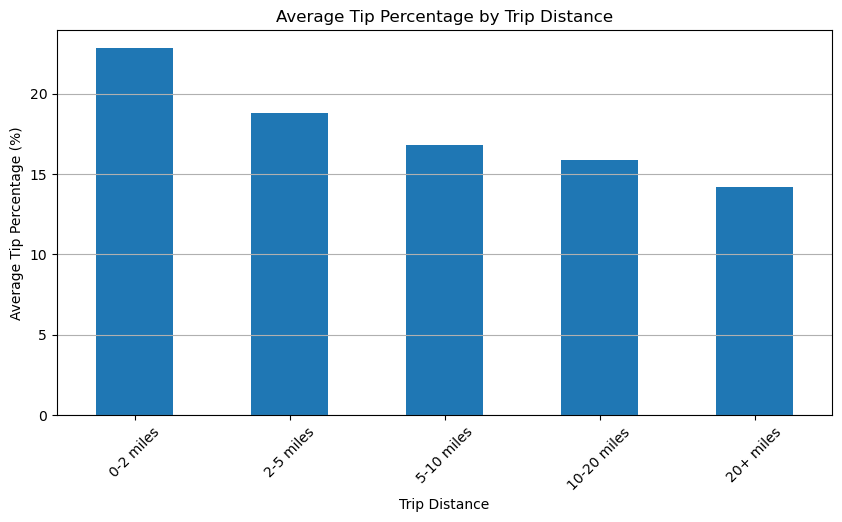

In [605]:
plt.figure(figsize=(10, 5))

avg_tip_by_distance.plot(kind='bar')

plt.title('Average Tip Percentage by Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [613]:
# Calculate average tip percentage by passenger count

tip_data = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

# Calculate tip percentage
tip_data['tip_percentage'] = (
    tip_data['tip_amount'] / tip_data['fare_amount']
) * 100

# Calculate average tip percentage for each passenger count
avg_tip_by_passengers = (
    tip_data
    .groupby('passenger_count')['tip_percentage']
    .mean()
)

display(avg_tip_by_passengers)

passenger_count
0.0    20.442484
1.0    20.815237
2.0    20.155226
3.0    19.258184
4.0    18.481740
5.0    20.796561
6.0    19.655206
Name: tip_percentage, dtype: float64

In [619]:
# Analyse average tip percentage by distance, passengers and pickup hour

tip_data = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

# Calculate tip percentage
tip_data['tip_percentage'] = (
    tip_data['tip_amount'] / tip_data['fare_amount']
) * 100

# Pickup hour
tip_data['pickup_hour'] = (
    tip_data['tpep_pickup_datetime'].dt.hour
)

# Average tip percentage by distance
avg_tip_by_distance = (
    tip_data
    .groupby('distance_tier', observed=True)['tip_percentage']
    .mean()
)

# Average tip percentage by passenger count
avg_tip_by_passengers = (
    tip_data
    .groupby('passenger_count')['tip_percentage']
    .mean()
)

# Average tip percentage by pickup hour
avg_tip_by_hour = (
    tip_data
    .groupby('pickup_hour')['tip_percentage']
    .mean()
    .sort_index()
)

# Lowest values
print("Lowest tip percentage by distance:")
print(avg_tip_by_distance.idxmin(),
      "=", round(avg_tip_by_distance.min(), 2), "%")

print("\nLowest tip percentage by passenger count:")
print(avg_tip_by_passengers.idxmin(),
      "=", round(avg_tip_by_passengers.min(), 2), "%")

print("\nLowest tip percentage by pickup hour:")
print(avg_tip_by_hour.idxmin(),
      "=", round(avg_tip_by_hour.min(), 2), "%")

Lowest tip percentage by distance:
20+ miles = 14.18 %

Lowest tip percentage by passenger count:
4.0 = 18.48 %

Lowest tip percentage by pickup hour:
4 = 16.43 %


In [623]:
# Analyze tip percentages based on distance, passenger count and pickup time

import matplotlib.pyplot as plt

# Keep valid trips
tip_data = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

# Calculate tip percentage
tip_data['tip_percentage'] = (
    tip_data['tip_amount'] / tip_data['fare_amount']
) * 100

# Create pickup hour
tip_data['pickup_hour'] = (
    tip_data['tpep_pickup_datetime'].dt.hour
)

# Create distance tiers
bins = [0, 2, 5, 10, 20, float('inf')]

labels = [
    '0-2 miles',
    '2-5 miles',
    '5-10 miles',
    '10-20 miles',
    '20+ miles'
]

tip_data['distance_tier'] = pd.cut(
    tip_data['trip_distance'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Average tip percentage by distance
avg_tip_by_distance = (
    tip_data
    .groupby('distance_tier', observed=True)['tip_percentage']
    .mean()
)

# Average tip percentage by passenger count
avg_tip_by_passengers = (
    tip_data
    .groupby('passenger_count')['tip_percentage']
    .mean()
)

# Average tip percentage by pickup hour
avg_tip_by_hour = (
    tip_data
    .groupby('pickup_hour')['tip_percentage']
    .mean()
    .sort_index()
)

print("Average Tip Percentage by Distance:")
display(avg_tip_by_distance)

print("Average Tip Percentage by Passenger Count:")
display(avg_tip_by_passengers)

print("Average Tip Percentage by Pickup Hour:")
display(avg_tip_by_hour)


Average Tip Percentage by Distance:


distance_tier
0-2 miles      22.806779
2-5 miles      18.794712
5-10 miles     16.780629
10-20 miles    15.872734
20+ miles      14.183319
Name: tip_percentage, dtype: float64

Average Tip Percentage by Passenger Count:


passenger_count
0.0    20.442484
1.0    20.815237
2.0    20.155226
3.0    19.258184
4.0    18.481740
5.0    20.796561
6.0    19.655206
Name: tip_percentage, dtype: float64

Average Tip Percentage by Pickup Hour:


pickup_hour
0     20.284040
1     20.591559
2     20.689017
3     23.274726
4     16.429956
5     16.505873
6     18.386561
7     19.367821
8     19.931784
9     20.161124
10    19.581187
11    19.497930
12    19.413652
13    19.428518
14    19.184393
15    19.327240
16    21.381950
17    22.033729
18    22.690839
19    22.324432
20    21.652326
21    21.584004
22    21.268684
23    20.622774
Name: tip_percentage, dtype: float64

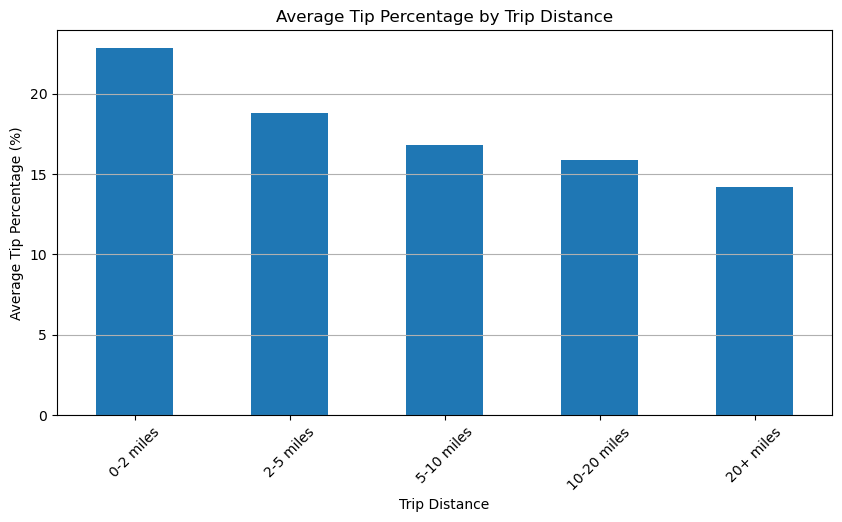

In [625]:
plt.figure(figsize=(10, 5))

avg_tip_by_distance.plot(kind='bar')

plt.title('Average Tip Percentage by Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

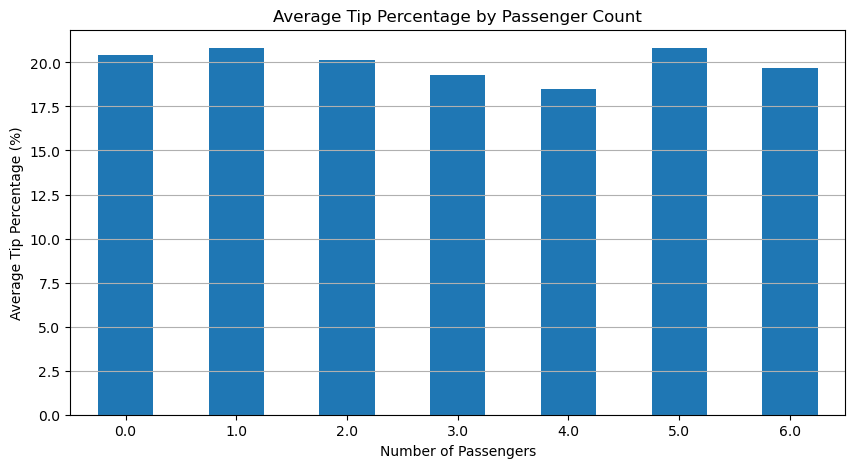

In [627]:
plt.figure(figsize=(10, 5))

avg_tip_by_passengers.plot(kind='bar')

plt.title('Average Tip Percentage by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

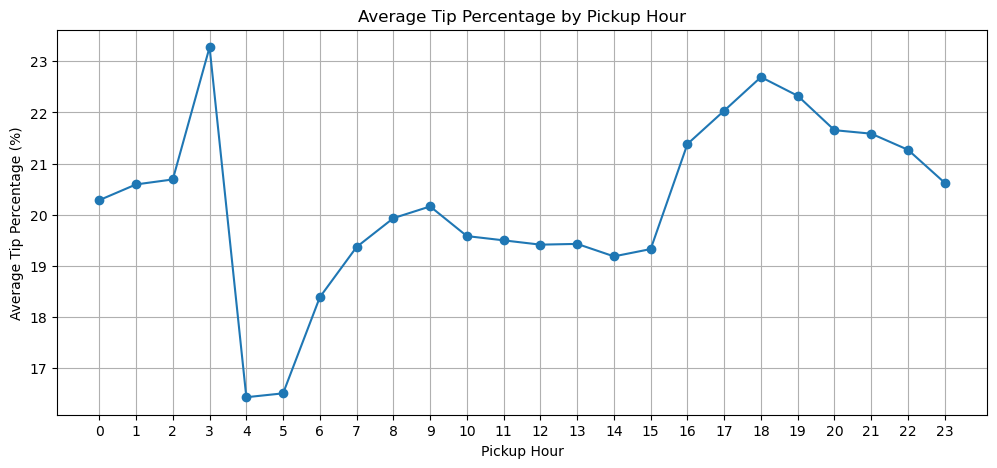

In [629]:
plt.figure(figsize=(12, 5))

avg_tip_by_hour.plot(kind='line', marker='o')

plt.title('Average Tip Percentage by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [631]:
print("Lowest tip percentage by distance:")
print(
    avg_tip_by_distance.idxmin(),
    "=",
    round(avg_tip_by_distance.min(), 2),
    "%"
)

print("\nLowest tip percentage by passenger count:")
print(
    avg_tip_by_passengers.idxmin(),
    "=",
    round(avg_tip_by_passengers.min(), 2),
    "%"
)

print("\nLowest tip percentage by pickup hour:")
print(
    avg_tip_by_hour.idxmin(),
    "=",
    round(avg_tip_by_hour.min(), 2),
    "%"
)

Lowest tip percentage by distance:
20+ miles = 14.18 %

Lowest tip percentage by passenger count:
4.0 = 18.48 %

Lowest tip percentage by pickup hour:
4 = 16.43 %


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [643]:
# Compare trips with tip percentage < 10% and > 25%

low_tip_trips = tip_data[
    tip_data['tip_percentage'] < 10
].copy()

high_tip_trips = tip_data[
    tip_data['tip_percentage'] > 25
].copy()

print("Trips with tip percentage < 10%:", len(low_tip_trips))
print("Trips with tip percentage > 25%:", len(high_tip_trips))


Trips with tip percentage < 10%: 76246
Trips with tip percentage > 25%: 135550


In [645]:
comparison = pd.DataFrame({
    'Metric': [
        'Number of Trips',
        'Average Trip Distance',
        'Average Fare',
        'Average Tip',
        'Average Passenger Count',
        'Average Trip Duration'
    ],
    
    'Tip < 10%': [
        len(low_tip_trips),
        low_tip_trips['trip_distance'].mean(),
        low_tip_trips['fare_amount'].mean(),
        low_tip_trips['tip_amount'].mean(),
        low_tip_trips['passenger_count'].mean(),
        low_tip_trips['trip_duration'].mean()
    ],
    
    'Tip > 25%': [
        len(high_tip_trips),
        high_tip_trips['trip_distance'].mean(),
        high_tip_trips['fare_amount'].mean(),
        high_tip_trips['tip_amount'].mean(),
        high_tip_trips['passenger_count'].mean(),
        high_tip_trips['trip_duration'].mean()
    ]
})

comparison

,Metric,Tip < 10%,Tip > 25%
0,Number of Trips,76246.000000,135550.000000
1,Average Trip Distance,3.854106,2.230053
2,Average Fare,20.319310,13.577611
3,Average Tip,0.267836,4.197326
4,Average Passenger Count,1.396086,1.347532
5,Average Trip Duration,18.031667,11.583731


In [647]:
low_tip_hour = (
    low_tip_trips
    .groupby('pickup_hour')
    .size()
)

high_tip_hour = (
    high_tip_trips
    .groupby('pickup_hour')
    .size()
)

hour_comparison = pd.DataFrame({
    'Tip < 10%': low_tip_hour,
    'Tip > 25%': high_tip_hour
}).fillna(0)

hour_comparison

,Tip < 10%,Tip > 25%
pickup_hour,,
0,2132,3638
1,1442,2522
2,1134,1822
3,818,1118
4,656,568
5,658,526
6,1274,1574
7,2148,3328
8,2738,4730


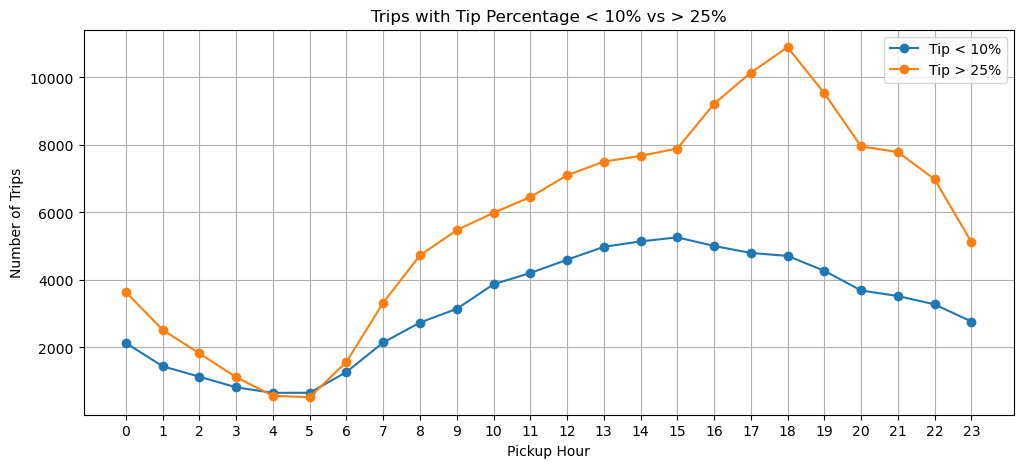

In [649]:
hour_comparison.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Trips with Tip Percentage < 10% vs > 25%')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.grid(True)

plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [655]:
# See how passenger count varies across hours and days

import matplotlib.pyplot as plt

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

# Average passenger count by hour
avg_passengers_by_hour = (
    df.groupby('pickup_hour')['passenger_count']
    .mean()
    .sort_index()
)

display(avg_passengers_by_hour)



pickup_hour
0     1.445508
1     1.447803
2     1.456543
3     1.444961
4     1.327251
5     1.324910
6     1.276825
7     1.279019
8     1.263613
9     1.298796
10    1.352335
11    1.323874
12    1.371380
13    1.358889
14    1.349344
15    1.384960
16    1.360675
17    1.369967
18    1.353560
19    1.349171
20    1.382050
21    1.395002
22    1.426800
23    1.393732
Name: passenger_count, dtype: float64

In [657]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

avg_passengers_by_day = (
    df.groupby('day_of_week')['passenger_count']
    .mean()
    .reindex(day_order)
)

display(avg_passengers_by_day)

day_of_week
Monday       1.352123
Tuesday      1.311618
Wednesday    1.299931
Thursday     1.319156
Friday       1.366088
Saturday     1.441876
Sunday       1.449672
Name: passenger_count, dtype: float64

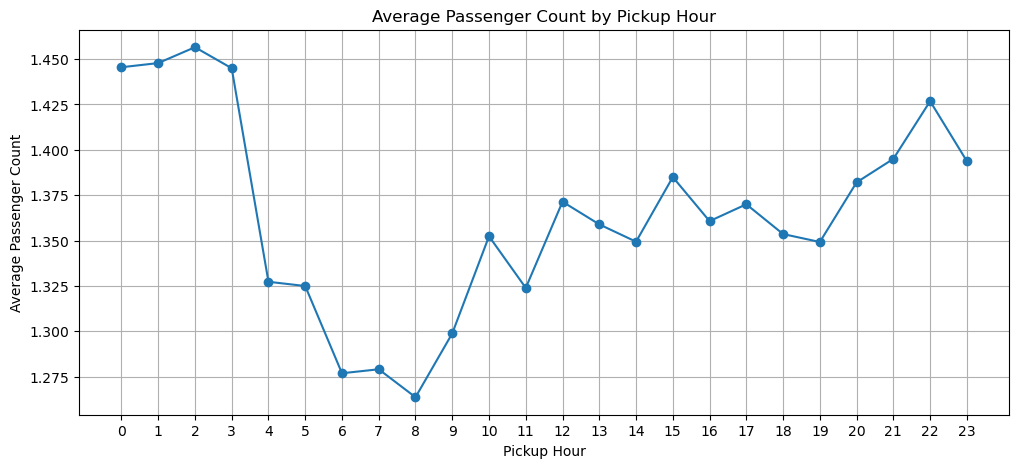

In [659]:
plt.figure(figsize=(12, 5))

avg_passengers_by_hour.plot(
    kind='line',
    marker='o'
)

plt.title('Average Passenger Count by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Passenger Count')
plt.xticks(range(24))
plt.grid(True)

plt.show()

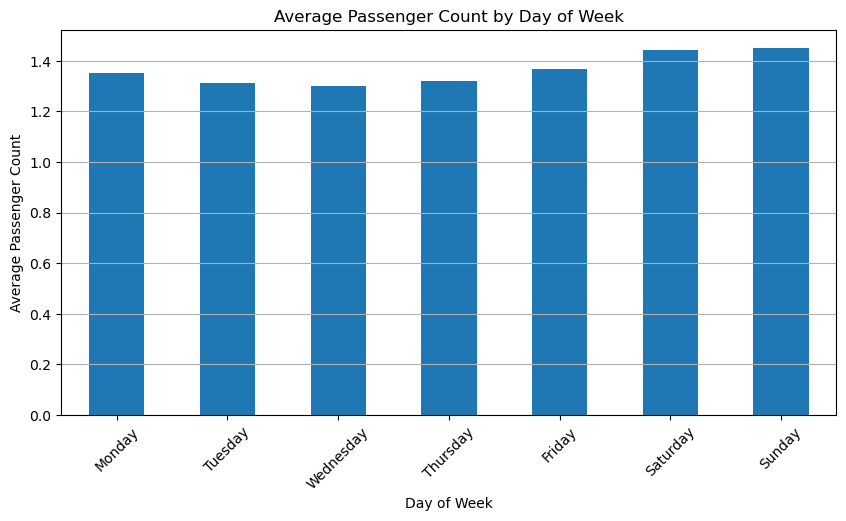

In [660]:
plt.figure(figsize=(10, 5))

avg_passengers_by_day.plot(kind='bar')

plt.title('Average Passenger Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Passenger Count')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [663]:
print(
    "Highest average passenger count by hour:",
    avg_passengers_by_hour.idxmax(),
    "=", round(avg_passengers_by_hour.max(), 2)
)

print(
    "Lowest average passenger count by hour:",
    avg_passengers_by_hour.idxmin(),
    "=", round(avg_passengers_by_hour.min(), 2)
)

print(
    "Highest average passenger count by day:",
    avg_passengers_by_day.idxmax(),
    "=", round(avg_passengers_by_day.max(), 2)
)

print(
    "Lowest average passenger count by day:",
    avg_passengers_by_day.idxmin(),
    "=", round(avg_passengers_by_day.min(), 2)
)

Highest average passenger count by hour: 2 = 1.46
Lowest average passenger count by hour: 8 = 1.26
Highest average passenger count by day: Sunday = 1.45
Lowest average passenger count by day: Wednesday = 1.3


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [668]:
# How does passenger count vary across zones?

zone_passengers = (
    df.groupby('PULocationID')['passenger_count']
    .agg(['mean', 'count'])
    .reset_index()
)

zone_passengers.columns = [
    'LocationID',
    'Average_Passenger_Count',
    'Trip_Count'
]

# Add zone names
zone_passengers = zone_passengers.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID',
    how='left'
)

# Sort by average passenger count
zone_passengers = zone_passengers.sort_values(
    'Average_Passenger_Count',
    ascending=False
)

display(zone_passengers.head(20))


,LocationID,Average_Passenger_Count,Trip_Count,zone,borough
28,34,3.500000,4,Brooklyn Navy Yard,Brooklyn
153,178,2.500000,4,Ocean Parkway South,Brooklyn
112,133,2.000000,4,Kensington,Brooklyn
73,85,2.000000,2,Erasmus,Brooklyn
49,56,1.777778,18,Corona,Queens
50,56,1.777778,18,Corona,Queens
101,121,1.750000,8,Hillcrest/Pomonok,Queens
8,12,1.743590,78,Battery Park,Manhattan
85,97,1.702703,74,Fort Greene,Brooklyn
175,202,1.666667,12,Roosevelt Island,Manhattan


In [670]:
print("Top 10 zones by average passenger count:")

display(
    zone_passengers[
        ['LocationID', 'zone', 'borough',
         'Average_Passenger_Count', 'Trip_Count']
    ].head(10)
)

print("\nBottom 10 zones by average passenger count:")

display(
    zone_passengers[
        ['LocationID', 'zone', 'borough',
         'Average_Passenger_Count', 'Trip_Count']
    ].tail(10)
)

Top 10 zones by average passenger count:


,LocationID,zone,borough,Average_Passenger_Count,Trip_Count
28,34,Brooklyn Navy Yard,Brooklyn,3.500000,4
153,178,Ocean Parkway South,Brooklyn,2.500000,4
112,133,Kensington,Brooklyn,2.000000,4
73,85,Erasmus,Brooklyn,2.000000,2
49,56,Corona,Queens,1.777778,18
50,56,Corona,Queens,1.777778,18
101,121,Hillcrest/Pomonok,Queens,1.750000,8
8,12,Battery Park,Manhattan,1.743590,78
85,97,Fort Greene,Brooklyn,1.702703,74
175,202,Roosevelt Island,Manhattan,1.666667,12



Bottom 10 zones by average passenger count:


,LocationID,zone,borough,Average_Passenger_Count,Trip_Count
59,69,East Concourse/Concourse Village,Bronx,1.000000,16
142,165,Midwood,Brooklyn,1.000000,16
61,71,East Flatbush/Farragut,Brooklyn,1.000000,14
45,52,Cobble Hill,Brooklyn,1.000000,48
42,49,Clinton Hill,Brooklyn,0.941176,34
192,219,Springfield Gardens South,Queens,0.937500,32
162,188,Prospect-Lefferts Gardens,Brooklyn,0.933333,30
14,18,Bedford Park,Bronx,0.800000,10
99,119,Highbridge,Bronx,0.750000,8
40,47,Claremont/Bathgate,Bronx,0.000000,2


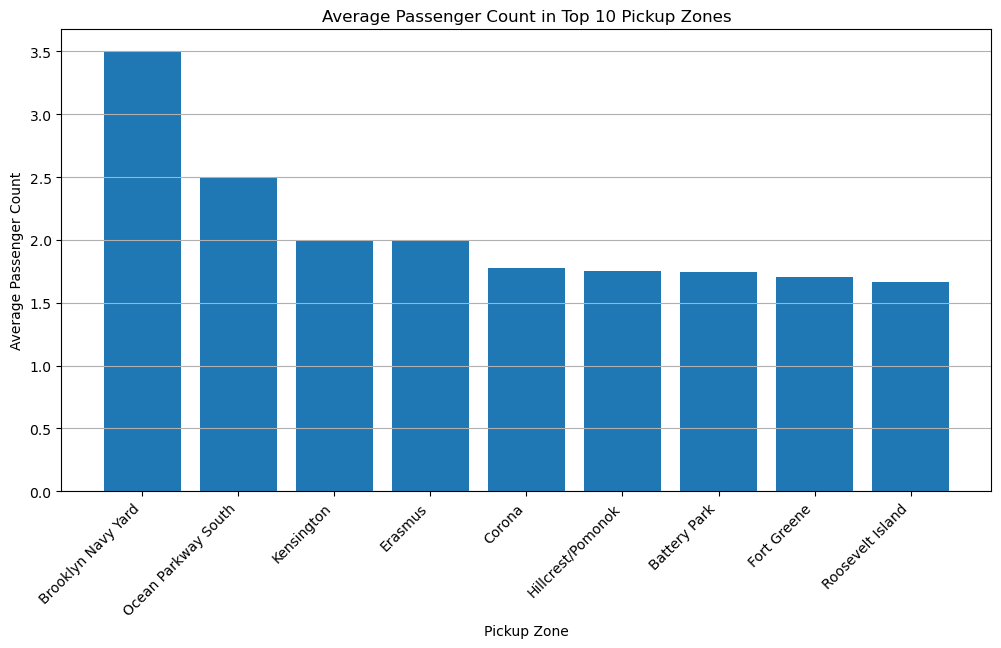

In [674]:
top_10_zones = zone_passengers.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_zones['zone'],
    top_10_zones['Average_Passenger_Count']
)

plt.title('Average Passenger Count in Top 10 Pickup Zones')
plt.xlabel('Pickup Zone')
plt.ylabel('Average Passenger Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

In [689]:
# For detailed analysis: average passenger count in each zone

# Step 1: Calculate average passenger count for each pickup zone
avg_passengers_by_zone = (
    df.groupby('PULocationID')['passenger_count']
    .mean()
    .reset_index()
)

avg_passengers_by_zone.columns = [
    'LocationID',
    'avg_passenger_count'
]

# Step 2: Calculate total trips for each zone
trips_per_location = (
    df.groupby('PULocationID')
    .size()
    .reset_index(name='total_trips')
)

# Step 3: Create zones_with_trips GeoDataFrame
zones_with_trips = zones.merge(
    trips_per_location,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

zones_with_trips['total_trips'] = (
    zones_with_trips['total_trips'].fillna(0)
)

# Step 4: Add average passenger count to zones_with_trips
zones_with_trips = zones_with_trips.merge(
    avg_passengers_by_zone,
    on='LocationID',
    how='left'
)

# Step 5: Display the result
zones_with_trips[
    [
        'LocationID',
        'zone',
        'borough',
        'total_trips',
        'avg_passenger_count'
    ]
].head(20)

,LocationID,zone,borough,total_trips,avg_passenger_count
0,1,Newark Airport,EWR,30.0,1.333333
1,2,Jamaica Bay,Queens,0.0,NaN
2,3,Allerton/Pelham Gardens,Bronx,12.0,1.000000
3,4,Alphabet City,Manhattan,292.0,1.486301
4,5,Arden Heights,Staten Island,0.0,NaN
5,6,Arrochar/Fort Wadsworth,Staten Island,12.0,1.666667
6,7,Astoria,Queens,132.0,1.212121
7,8,Astoria Park,Queens,0.0,NaN
8,9,Auburndale,Queens,2.0,1.000000
9,10,Baisley Park,Queens,140.0,1.257143


Find out how often surcharges/extra charges are applied to understand their prevalance

In [699]:
# Calculate average passenger count for each pickup zone

avg_passengers_by_zone = (
    df.groupby('PULocationID')['passenger_count']
    .mean()
    .reset_index()
)

avg_passengers_by_zone.columns = [
    'LocationID',
    'avg_passenger_count'
]

# Add the average passenger count to zones_with_trips
zones_with_trips = zones_with_trips.merge(
    avg_passengers_by_zone,
    on='LocationID',
    how='left'
)

# Display the result
display(
    zones_with_trips[
        [
            'LocationID',
            'zone',
            'borough',
            'total_trips',
            'avg_passenger_count'
        ]
    ].head(20)
)

KeyError: "['avg_passenger_count'] not in index"

In [701]:
# Remove old average passenger column if it already exists
if 'avg_passenger_count' in zones_with_trips.columns:
    zones_with_trips = zones_with_trips.drop(
        columns=['avg_passenger_count']
    )

# Calculate average passenger count
avg_passengers_by_zone = (
    df.groupby('PULocationID')['passenger_count']
    .mean()
    .reset_index()
)

avg_passengers_by_zone.columns = [
    'LocationID',
    'avg_passenger_count'
]

# Merge
zones_with_trips = zones_with_trips.merge(
    avg_passengers_by_zone,
    on='LocationID',
    how='left'
)

display(
    zones_with_trips[
        [
            'LocationID',
            'zone',
            'borough',
            'total_trips',
            'avg_passenger_count'
        ]
    ].head(20)
)

,LocationID,zone,borough,total_trips,avg_passenger_count
0,1,Newark Airport,EWR,30.0,1.333333
1,2,Jamaica Bay,Queens,0.0,NaN
2,3,Allerton/Pelham Gardens,Bronx,12.0,1.000000
3,4,Alphabet City,Manhattan,292.0,1.486301
4,5,Arden Heights,Staten Island,0.0,NaN
5,6,Arrochar/Fort Wadsworth,Staten Island,12.0,1.666667
6,7,Astoria,Queens,132.0,1.212121
7,8,Astoria Park,Queens,0.0,NaN
8,9,Auburndale,Queens,2.0,1.000000
9,10,Baisley Park,Queens,140.0,1.257143


**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [707]:
# How often is each surcharge applied?

surcharge_cols = [
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee'
]

surcharge_frequency = pd.DataFrame({
    'Surcharge': surcharge_cols,
    'Trips_Applied': [
        (df[col] > 0).sum() for col in surcharge_cols
    ]
})

surcharge_frequency['Percentage_of_Trips'] = (
    surcharge_frequency['Trips_Applied'] / len(df) * 100
)

surcharge_frequency = surcharge_frequency.sort_values(
    'Trips_Applied',
    ascending=False
)

display(surcharge_frequency)


,Surcharge,Trips_Applied,Percentage_of_Trips
3,improvement_surcharge,296852,99.972384
1,mta_tax,294694,99.245624
4,congestion_surcharge,274422,92.418517
0,extra,181682,61.185987
5,airport_fee,25906,8.724498
2,tolls_amount,22098,7.442058


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
### Recommendations to Optimize Routing and Dispatching

Based on the analysis of taxi demand patterns and operational inefficiencies, the following recommendations can help optimize routing and dispatching:

1. Prioritize high-demand zones:** Deploy more taxis to zones with consistently high pickup demand, especially during their identified peak hours. This can reduce customer waiting time and improve taxi utilization.

2. Use time-based dispatching:** Adjust taxi availability according to hourly demand patterns. More taxis should be dispatched during peak hours, while supply can be reduced or repositioned during low-demand periods.

3. Create separate weekday and weekend strategies:** Since demand patterns differ between weekdays and weekends, dispatching schedules should be designed separately for these periods.

4. Optimize night-time dispatching:** Use the identified high-demand zones between 11 PM and 5 AM to position taxis in advance. Night-time demand should be planned separately from overall daily demand.

5. Monitor pickup-drop-off imbalances:** Zones with significantly more pickups than drop-offs may experience a shortage of available taxis, while zones with more drop-offs may have excess taxi availability. Repositioning taxis between such zones can improve supply balance.

6. Avoid slow routes during peak periods:** Routes with consistently low average speeds should be monitored during the corresponding hours. Where possible, drivers can be directed toward alternative routes to reduce travel time and improve taxi availability.

7. Use real-time demand information:** Historical demand patterns can be combined with real-time pickup requests to dynamically dispatch taxis toward areas where demand is increasing.

8. Reduce empty travel:** Dispatch the nearest suitable available taxi to a customer instead of sending taxis from distant locations. This can reduce unnecessary mileage, fuel consumption and driver idle time.

9. Consider trip duration when dispatching:** A taxi assigned to a long-duration trip will remain unavailable for longer. Dispatching systems should therefore consider expected trip duration when estimating future taxi availability.

10. Continuously monitor performance:** Track indicators such as customer waiting time, taxi idle time, trip completion time, route speed and pickup demand by zone and hour. These measures can be used to continuously improve routing and dispatching decisions.

Overall, routing and dispatching should be **demand-driven rather than uniform**. Combining location, time of day, day of week, route speed, trip duration and pickup-drop-off patterns can help allocate taxis more efficiently, reduce idle time and improve customer service.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
### Suggestions for Strategically Positioning Cabs Across Different Zones

Based on the analysis of trip trends across different hours, days, months and geographical zones, cab positioning should be adjusted dynamically according to expected customer demand.

1. Position more cabs in high-demand pickup zones:** Zones with consistently high pickup volumes should receive a larger share of the available fleet. Additional cabs should be positioned in these areas before the expected peak demand period begins.

2. Use hourly demand patterns:** Cab positioning should change throughout the day. More cabs can be moved toward zones that experience higher demand during morning, afternoon and evening peak periods, while excess cabs in low-demand areas can be repositioned.

3. Plan separately for weekdays and weekends:** Weekday demand patterns can differ from weekend patterns. Therefore, cab locations should be adjusted according to the expected demand for each day rather than following the same allocation throughout the week.

4. Create a separate night-time positioning strategy:** The analysis of 11 PM–5 AM demand identifies zones that are specifically busy during night hours. Cabs should be positioned near these zones before late-night demand increases to reduce customer waiting time.

5. Consider pickup and drop-off imbalances:** Zones with substantially higher pickup activity than drop-off activity may require additional cabs, while zones receiving many drop-offs may have more available taxis. Cabs can be repositioned between such zones to maintain a better supply-demand balance.

6. Use monthly trends for seasonal planning:** Monthly variations in trip volume and revenue should be considered when planning fleet allocation. More cabs can be made available in months with higher observed demand, while maintenance or lower fleet deployment can be considered during relatively lower-demand periods.

7. Consider route efficiency:** Zones connected by routes with lower average speeds may require additional planning because cabs can remain occupied for longer periods. Dispatching nearby available cabs and considering alternative routes can help maintain service levels.

8.Use a dynamic repositioning approach:** Instead of keeping cabs permanently assigned to particular zones, the fleet should be repositioned based on changing demand. Historical trip patterns can be used to predict demand, while real-time requests can be used to make short-term adjustments.

Overall, the analysis suggests that **cab positioning should depend on location, hour, day of the week and month**. A flexible positioning strategy that moves cabs toward high-demand zones before demand peaks, while correcting pickup-drop-off imbalances, can improve taxi availability, reduce idle time and make better use of the available fleet.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
### Data-Driven Adjustments to the Pricing Strategy

Based on the analysis of trip distance, trip duration, fare per mile, time of day, day of the week, passenger count, tips, vendors and surcharges, the following data-driven pricing recommendations can be considered:

1. Use distance and duration as key pricing parameters:** The analysis indicates that fare amount has a stronger relationship with trip distance and trip duration than with passenger count. Pricing should therefore reflect both the distance travelled and the time required to complete a trip.

2. Monitor fare per mile by time of day:** Since average fare per mile varies across different hours, pricing performance should be monitored by hour. Periods showing differences in demand and fare generation can be analysed to determine whether the existing pricing structure is appropriate.

3. Consider weekday and weekend demand separately:** Fare and demand patterns can differ between weekdays and weekends. Pricing and promotional strategies can therefore be evaluated separately for these two periods rather than applying identical strategies throughout the week.

4. Use location-based demand information:** High-demand pickup zones can be monitored for pricing and demand responsiveness. Where demand is consistently high, pricing can be reviewed while ensuring that rates remain competitive and transparent.

5. Account for peak and low-demand periods:** During periods of high demand, pricing can be adjusted within applicable pricing rules to reflect demand and operating costs. During low-demand periods, targeted promotions or incentives can be considered to encourage bookings and improve vehicle utilization.

6. Compare vendor performance:** The analysis of average fare per mile across vendors provides a useful benchmark. Vendor-level pricing should be compared using similar trip characteristics, such as distance, duration and location, rather than comparing simple overall averages.

7. Monitor surcharges separately:** The frequency of extra charges, tolls, congestion surcharge, airport fee and other applicable charges should be monitored. Customers should receive clear information about these charges so that the total trip price remains transparent.

8. Use tip behaviour as a supporting indicator:** Variations in tip percentages across distance, passenger count and pickup time can provide additional information about customer behaviour. However, tips should not be treated as a direct pricing variable because they are voluntary and influenced by factors beyond fare levels.

9. Test pricing changes using historical data:** Before implementing a pricing change, its potential effect can be evaluated using historical trip data. Important measures include trip volume, revenue per trip, fare per mile, customer demand and vehicle utilization.

10. Maintain competitive pricing:** Pricing decisions should balance revenue generation with customer demand and competitor/vendor pricing. Rather than maximizing the fare for every trip, the objective should be to identify pricing levels that support sustainable revenue while maintaining customer demand.

### Overall Recommendation

A data-driven and flexible pricing strategy** should consider trip distance, duration, demand by hour, day and location, vendor-level fare patterns and applicable surcharges. Pricing changes should be tested against historical performance and monitored using revenue, trip volume and utilization metrics. This approach can help improve revenue opportunities while maintaining transparent and competitive rates.
